<a href="https://colab.research.google.com/github/RPAlbuquerque/gsdm-spatial-ai/blob/main/i_guide_challenge_spatial_ai_final_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From Mobility Intensity to Market Infrastructure: A Spatial AI Framework for Recovering Hidden Regime Structure and Multiscale Variation

**Authors:** Rafael Albuquerque, Jessica Miranda, Sisi Wang, and Vinícius Brei

## Why This Notebook Matters

Locations that attracted similar levels of traffic often supported very different underlying local conditions. Some places exhibited concentrated recurring visitation, longer dwell times, and stable patterns of use that were more consistent with sustained local activation. Others registered substantial movement because of pass-through circulation, episodic concentration, or transient exposure. For firms choosing where to locate, entrepreneurs assessing local opportunity, and urban planners targeting revitalization, that distinction mattered. Decisions based on traffic alone could misclassify places that appeared active but did not support the same degree of persistent local engagement.

This notebook addressed that limitation by treating mobility not only as volume, but as a structured behavioral signal. Using nationwide tract-level mobility data from Brazil, we recovered a latent **Market Infrastructure Index (MII)**, identified geographically distinct **mobility infrastructure regimes**, evaluated their economic differentiation with **VIIRS nighttime light intensity**, and reconstructed sub-tract variation through **mass-preserving downscaling** in São Paulo. The notebook, therefore, showed how mobility data could reveal a hidden spatial structure that traffic alone could not recover.

## Evaluator Setup and Run

This notebook was designed as a single-notebook, evaluator-facing workflow for the I-GUIDE challenge. It ran from two platform-hosted assets and did not require absolute local paths, hidden preprocessing directories, or off-notebook intermediate products.

**Inputs**
- `mii_brazil_analysis_ready.gpkg.zip`: tract geometry, tract identifiers, standardized mobility indicators, stored `mii`, and stored `mii_norm`
- `VIIRS_annual_2024.zip`: annual georeferenced nighttime light raster tiles used for external economic validation and multiscale reconstruction

**Environment**
- Core libraries used in this notebook included `geopandas`, `pandas`, `rasterio`, `pyogrio`, `matplotlib`, `seaborn`, `scikit-learn`, `rasterstats`, `patsy`, and `shapely`
- The setup cells below included commented `%pip install` lines for clean environments

**Run Order**
- Run the notebook from top to bottom
- Section 2 downloaded, extracted, and verified the two shared assets
- Later sections reused those staged files and derived all remaining analytical outputs in the notebook

**Expected Outputs**
- verification of the analysis-ready GeoPackage and VIIRS archive
- reconstruction and validation of the latent MII structure
- national mobility infrastructure regimes and regime maps
- economic validation using tract-level nighttime light intensity
- São Paulo downscaling and intra-tract fragmentation diagnostics

**Evaluation Note**
- The notebook reproduced the analytical workflow from shared assets only
- No hidden preprocessing step was required for notebook execution
- The mobility source data were proprietary, but the analytical-stage assets required for this notebook were shared directly through the platform

## Conceptual Pipeline

The notebook followed a four-stage analytical logic. It began from a decision problem in which traffic intensity alone could not distinguish places with different underlying local conditions. It then recovered a latent mobility-based infrastructure field, identified spatially differentiated regimes, evaluated their economic meaning, and finally reconstructed sub-tract variation that tract-level representation concealed.

```mermaid
flowchart TD
    A["Real-world problem<br/>Traffic counts and static proxies could not distinguish transient exposure from stable local activation"] --> B["Shared inputs<br/>Analysis-ready GeoPackage<br/>VIIRS annual nighttime lights archive"]
    B --> C["Stage 1: Latent structure recovery<br/>Construct and verify the Market Infrastructure Index (MII)"]
    C --> D["Stage 2: Spatial regime discovery<br/>Recover localized mobility infrastructure regimes"]
    D --> E["Stage 3: External economic validation<br/>Test whether regimes correspond to distinct economic environments using VIIRS"]
    E --> F["Stage 4: Multiscale reconstruction<br/>Redistribute tract-level structure to a 100 m grid in São Paulo"]
    F --> G["Evaluator-facing outputs<br/>MII evidence, regime maps, economic differentiation, and intra-tract fragmentation diagnostics"]

## Notebook Roadmap

1. **Introduction**  
We defined the motivating decision problem, explained why existing signals were insufficient, and stated the research question.

2. **Data and Operational Inputs**  
We introduced the two shared assets, staged them locally, and verified that they were sufficient for the full workflow.

3. **From Mobility Signals to the MII**  
We showed how the standardized mobility indicators supported a dominant latent dimension and verified its alignment with the stored index.

4. **Spatial Regime Discovery**  
We recovered geographically varying mobility infrastructure regimes from localized covariance structure.

5. **External Economic Validation**  
We tested whether the recovered regimes corresponded to distinct economic environments using VIIRS nighttime light intensity.

6. **Multiscale Reconstruction**  
We demonstrated how mass-preserving downscaling revealed sub-tract differentiation hidden by tract-level representation.

7. **Key Takeaways, Limitations, and Reproducibility**  
We summarized the empirical findings, clarified the framework's scope, and restated the notebook’s reproducible logic.


# 1. Introduction

Locations that attracted similar levels of traffic often supported very different underlying local conditions. Some places exhibited concentrated recurring visitation, longer dwell times, and stable patterns of use that were more consistent with sustained local activation. Others registered substantial movement because of pass-through circulation, episodic concentration, or transient exposure. For firms choosing where to locate, entrepreneurs assessing local opportunity, and urban planners targeting revitalization, that distinction mattered. Decisions based on traffic alone could misclassify places that appeared active but did not support the same degree of persistent local engagement.

Conventional signals did not resolve that problem well. Traffic counts captured movement volume, but they did not reveal whether observed activity reflected repeated access, stable visitation, or durable local use. Static territorial proxies such as density, land use, and socioeconomic composition described broad contextual conditions, but they did not directly observe how people returned to places, how long they stayed, or how regularly activity was sustained over time. As a result, locations that looked similar under standard indicators could differ materially in the behavioral conditions that supported local economic intensity.

We addressed this gap by treating mobility not only as volume, but as a structured behavioral signal. We conceptualized **market infrastructure** as the latent spatial organization of access conditions associated with repeated visitation, temporal stability, and sustained local interaction. We did not use the term to denote market outcomes directly, nor did we restrict it to visible physical infrastructure. Instead, we used it to describe an underlying spatial condition inferred from the organization of mobility behavior across places.

This distinction was operationally important. Two locations could exhibit similar mobility intensity while differing sharply in visitor diversity, repeat visitation, dwell time, and temporal regularity. Those differences indicated whether movement mainly passed through space or unfolded in patterns more consistent with recurring engagement and economically meaningful local activation. We therefore asked:

**Can a latent form of market infrastructure be identified from spatial patterns of human mobility, and can it explain spatial differences in local economic intensity?**

To answer that question, we developed a Spatial AI workflow that combined tract-level mobility indicators, dimensionality reduction, spatial regime discovery, external economic validation, and multiscale reconstruction. We constructed the **Market Infrastructure Index (MII)** from the dominant covariance structure of mobility behavior, identified **mobility infrastructure regimes** across Brazil’s census tracts, evaluated their association with **VIIRS nighttime light intensity**, and implemented **mass-preserving downscaling** in São Paulo to recover sub-tract variation at 100-meter resolution.

This notebook tested whether mobility data could do more than describe movement intensity. It examined whether behaviorally structured mobility signals could recover a latent, spatially differentiated, and decision-relevant infrastructure field that conventional traffic measures could not reveal.

# 2. Data and Operational Inputs

## 2.1 Why These Inputs Are Sufficient

This notebook was designed to run from two shared, platform-hosted assets that fully supported the analytical workflow. Rather than requiring reviewers to reconstruct internal preprocessing stages, we began from the final analytical inputs used in the study: an analysis-ready tract-level GeoPackage and a VIIRS nighttime lights archive.

These two inputs were sufficient because they covered the full set of objects required for notebook execution. The GeoPackage supplied tract geometry, tract identifiers, standardized mobility indicators, and the stored infrastructure fields used throughout the national analysis. The VIIRS archive supplied the external economic proxy used for validation and the ancillary raster surface used for multiscale redistribution. Together, they supported data verification, latent structure recovery, spatial regime discovery, economic validation, and downscaling within a single notebook workflow.

This design also served a reproducibility purpose. Reviewers did not need access to absolute local paths, hidden working directories, or undocumented intermediate products. They only needed the two shared assets introduced here.

## 2.2 Asset Ledger

The table below summarized the operational role of each shared input, the fields or contents required for notebook execution, what was treated as shared versus recomputed, and which outputs each asset supported.

In [ ]:
# ============================================================
# SECTION 2 — Imports, platform asset configuration, and ledger
# ============================================================

from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile
import warnings

import geopandas as gpd
import pandas as pd
import rasterio
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

analysis_url = "https://storage.i-guide.io/datasets/82aba7f7-4562-49ab-8424-afbe5a576ea7/mii_brazil_analysis_ready.gpkg.zip"
viirs_url = "https://storage.i-guide.io/datasets/0a527d5d-e7d3-4bc4-8189-e5d3e0aa2a05/VIIRS_annual_2024.zip"

project_dir = Path("i_guide_market_infrastructure")
data_dir = project_dir / "data"

analysis_zip_path = data_dir / "mii_brazil_analysis_ready.gpkg.zip"
viirs_zip_path = data_dir / "VIIRS_annual_2024.zip"

analysis_extract_dir = data_dir / "analysis_ready_asset"
viirs_extract_dir = data_dir / "viirs_2024_asset"

asset_ledger = pd.DataFrame(
    [
        {
            "asset": "Analysis-ready GeoPackage",
            "shared_file": "mii_brazil_analysis_ready.gpkg.zip",
            "role_in_notebook": "Tract-level analytical base for the national workflow",
            "required_fields_or_contents": "ct_id, geometry, mii, mii_norm, and the seven standardized mobility indicators",
            "shared_or_recomputed": "Shared input; mii and mii_norm are provided; PCA alignment and downstream analytical products are recomputed in notebook",
            "supports_outputs": "GeoPackage verification, MII validation, regime discovery, regime mapping, economic validation joins, Sao Paulo tract subset, downscaling base surface, fragmentation diagnostics",
            "url": analysis_url,
            "local_zip": str(analysis_zip_path),
            "extract_dir": str(analysis_extract_dir),
        },
        {
            "asset": "VIIRS annual nighttime lights archive",
            "shared_file": "VIIRS_annual_2024.zip",
            "role_in_notebook": "External economic benchmark and ancillary raster layer for redistribution",
            "required_fields_or_contents": "Georeferenced annual raster tiles in TIFF format",
            "shared_or_recomputed": "Shared input; tract-level light summaries and the Sao Paulo ancillary surface are recomputed in notebook",
            "supports_outputs": "VIIRS verification, tract-level nighttime light extraction, regime-level economic comparison, spline response profiles, Sao Paulo downscaling weights",
            "url": viirs_url,
            "local_zip": str(viirs_zip_path),
            "extract_dir": str(viirs_extract_dir),
        },
    ]
)

display(asset_ledger)

,asset,shared_file,role_in_notebook,required_fields_or_contents,shared_or_recomputed,supports_outputs,url,local_zip,extract_dir
0,Analysis-ready GeoPackage,mii_brazil_analysis_ready.gpkg.zip,Tract-level analytical base for the national workflow,"ct_id, geometry, mii, mii_norm, and the seven standardized mobility indicators",Shared input; mii and mii_norm are provided; PCA alignment and downstream analytical products are recomputed in note...,"GeoPackage verification, MII validation, regime discovery, regime mapping, economic validation joins, Sao Paulo trac...",https://storage.i-guide.io/datasets/82aba7f7-4562-49ab-8424-afbe5a576ea7/mii_brazil_analysis_ready.gpkg.zip,i_guide_market_infrastructure/data/mii_brazil_analysis_ready.gpkg.zip,i_guide_market_infrastructure/data/analysis_ready_asset
1,VIIRS annual nighttime lights archive,VIIRS_annual_2024.zip,External economic benchmark and ancillary raster layer for redistribution,Georeferenced annual raster tiles in TIFF format,Shared input; tract-level light summaries and the Sao Paulo ancillary surface are recomputed in notebook,"VIIRS verification, tract-level nighttime light extraction, regime-level economic comparison, spline response profil...",https://storage.i-guide.io/datasets/0a527d5d-e7d3-4bc4-8189-e5d3e0aa2a05/VIIRS_annual_2024.zip,i_guide_market_infrastructure/data/VIIRS_annual_2024.zip,i_guide_market_infrastructure/data/viirs_2024_asset


## 2.3 Setup, Download, and Local Staging

The next cells set up the notebook. They imported the required libraries, defined helper functions, downloaded the shared files into a local project directory, extracted the ZIP archives, and located the staged GeoPackage and raster tiles.

This step mattered for evaluation because it made the notebook’s file logic explicit. All paths were created relative to the local project directory, and the notebook used cached downloads and cached extraction when files were already present. The staging workflow remained portable across environments and avoided any dependence on hidden local file systems.


In [ ]:
# ============================================================
# SECTION 2 — Helper functions for staging and verification
# ============================================================

# If you are running this notebook in a clean environment,
# uncomment the next line and install the required libraries:
# %pip install -q geopandas rasterio pyogrio


def download_file(url: str, output_path: Path) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Using cached file: {output_path.name}")
        return output_path

    print(f"Downloading: {output_path.name}")
    urlretrieve(url, output_path)
    print(f"Saved to: {output_path}")
    return output_path


def unzip_file(zip_path: Path, extract_dir: Path) -> Path:
    zip_path = Path(zip_path)
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    sentinel = extract_dir / ".unzipped"
    if sentinel.exists():
        print(f"Using cached extraction: {extract_dir}")
        return extract_dir

    print(f"Extracting: {zip_path.name}")
    with ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    sentinel.touch()
    print(f"Extracted to: {extract_dir}")
    return extract_dir


def is_valid_staged_file(path: Path) -> bool:
    return "__MACOSX" not in path.parts and not path.name.startswith("._")


def find_single_file(root_dir: Path, pattern: str) -> Path:
    matches = sorted(
        path for path in Path(root_dir).rglob(pattern)
        if is_valid_staged_file(path)
    )
    if not matches:
        raise FileNotFoundError(f"No valid files matched pattern '{pattern}' in {root_dir}")
    if len(matches) > 1:
        print(f"Multiple valid matches found for {pattern}. Using: {matches[0]}")
    return matches[0]


def summarize_viirs_tile(tile_path: Path) -> dict:
    with rasterio.open(tile_path) as src:
        arr = src.read(1, masked=True)
        return {
            "tile": tile_path.name,
            "shape": src.shape,
            "crs": str(src.crs),
            "bounds": str(src.bounds),
            "min": float(arr.min()),
            "max": float(arr.max()),
            "mean": float(arr.mean()),
        }

In [ ]:
# ============================================================
# SECTION 2 — Download and extract shared assets
# ============================================================

download_file(analysis_url, analysis_zip_path)
download_file(viirs_url, viirs_zip_path)

unzip_file(analysis_zip_path, analysis_extract_dir)
unzip_file(viirs_zip_path, viirs_extract_dir)

Using cached file: mii_brazil_analysis_ready.gpkg.zip
Using cached file: VIIRS_annual_2024.zip
Using cached extraction: i_guide_market_infrastructure/data/analysis_ready_asset
Using cached extraction: i_guide_market_infrastructure/data/viirs_2024_asset


PosixPath('i_guide_market_infrastructure/data/viirs_2024_asset')

In [ ]:
# ============================================================
# SECTION 2 — Locate staged files
# ============================================================

analysis_gpkg_path = find_single_file(analysis_extract_dir, "*.gpkg")
viirs_tiles = sorted(
    path for path in viirs_extract_dir.rglob("*.tif")
    if is_valid_staged_file(path)
)

staged_assets = pd.DataFrame(
    [
        {
            "asset": "Analysis-ready GeoPackage",
            "resolved_path": str(analysis_gpkg_path),
            "exists": analysis_gpkg_path.exists(),
            "n_files": 1,
        },
        {
            "asset": "VIIRS annual nighttime lights archive",
            "resolved_path": str(viirs_extract_dir),
            "exists": viirs_extract_dir.exists(),
            "n_files": len(viirs_tiles),
        },
    ]
)

display(staged_assets)

,asset,resolved_path,exists,n_files
0,Analysis-ready GeoPackage,i_guide_market_infrastructure/data/analysis_ready_asset/mii_brazil_analysis_ready.gpkg,True,1
1,VIIRS annual nighttime lights archive,i_guide_market_infrastructure/data/viirs_2024_asset,True,30


## 2.4 GeoPackage Verification

We next verified the analysis-ready GeoPackage that supported the tract-level analytical workflow. The checks below confirmed that the file could be loaded successfully, that it preserved a one-row-per-tract structure, and that it contained the fields required for the notebook’s downstream steps.

We treated four fields as core integrity checks for notebook execution: `ct_id`, `geometry`, `mii`, and `mii_norm`. We then inspected the broader column inventory to confirm that the standardized mobility indicators required later for PCA and regime discovery were also present. Passing these checks meant that the shared GeoPackage was structurally sufficient for the national analysis, index validation, mapping, regime discovery, and tract-based downscaling setup.

In [ ]:
# ============================================================
# SECTION 2.4 — Load and verify the analysis-ready GeoPackage
# ============================================================

if "analysis_gpkg_path" not in globals():
    raise RuntimeError("GeoPackage path is not available. Run the staging cells first.")

print("Resolved GeoPackage path:", analysis_gpkg_path)

if not analysis_gpkg_path.exists():
    raise FileNotFoundError(f"GeoPackage not found: {analysis_gpkg_path}")

gdf = gpd.read_file(analysis_gpkg_path)

required_columns = ["ct_id", "geometry", "mii", "mii_norm"]
missing_required_columns = [col for col in required_columns if col not in gdf.columns]

geo_checks = pd.DataFrame(
    {
        "check": [
            "Rows",
            "Unique ct_id",
            "Duplicated ct_id",
            "CRS",
            "Number of columns",
            "Missing required columns",
            "Missing ct_id",
            "Missing geometry",
            "Missing mii",
            "Missing mii_norm",
        ],
        "value": [
            len(gdf),
            gdf["ct_id"].nunique(),
            int(gdf["ct_id"].duplicated().sum()),
            str(gdf.crs),
            len(gdf.columns),
            "None" if not missing_required_columns else ", ".join(missing_required_columns),
            int(gdf["ct_id"].isna().sum()),
            int(gdf["geometry"].isna().sum()),
            int(gdf["mii"].isna().sum()),
            int(gdf["mii_norm"].isna().sum()),
        ],
    }
)

display(geo_checks)

Resolved GeoPackage path: i_guide_market_infrastructure/data/analysis_ready_asset/mii_brazil_analysis_ready.gpkg


,check,value
0,Rows,387779
1,Unique ct_id,387779
2,Duplicated ct_id,0
3,CRS,EPSG:4674
4,Number of columns,52
5,Missing required columns,None
6,Missing ct_id,0
7,Missing geometry,0
8,Missing mii,0
9,Missing mii_norm,0


In [ ]:
# ============================================================
# SECTION 2.4 — Column inventory and key-field preview
# ============================================================

if "gdf" not in globals():
    raise RuntimeError("GeoDataFrame 'gdf' is not available. Run the GeoPackage loading cell first.")

columns_df = pd.DataFrame(
    {
        "column_number": range(1, len(gdf.columns) + 1),
        "column_name": list(gdf.columns),
    }
)

preview_columns = [col for col in ["ct_id", "mii", "mii_norm"] if col in gdf.columns]

display(columns_df)
display(gdf[preview_columns].head())

,column_number,column_name
0,1,ct_id
1,2,unique
2,3,visits
3,4,repeat_visitors
4,5,new_visitors
5,6,unique_q1
6,7,unique_q2
7,8,unique_q3
8,9,unique_q4
9,10,visits_q1


,ct_id,mii,mii_norm
0,110001505000002,0.233157,0.681124
1,110001505000003,0.034297,0.636578
2,110001505000004,0.694699,0.784512
3,110001505000006,0.393506,0.717043
4,110001505000007,0.074617,0.645610


The verification checks showed that the shared GeoPackage preserved the tract-level structure required for the notebook. It loaded successfully, contained **387,779 census tracts**, retained a one-row-per-tract organization, and included the core analytical fields `ct_id`, `geometry`, `mii`, and `mii_norm` with no missing values. The dataset also preserved the broader mobility feature set required for the downstream analysis. This meant that the national workflow could proceed directly from the shared analytical asset without reconstructing hidden intermediate products.

## 2.5 VIIRS Verification

We then verified the VIIRS nighttime lights archive, which was later used for external economic validation and multiscale reconstruction. The checks below confirmed that the archive downloaded successfully, that raster tiles were present after extraction, and that the tiles carried valid geospatial metadata.

This verification step established that the notebook had access to the external economic proxy used to evaluate the recovered mobility infrastructure regimes. It also established that the ancillary raster input required for the São Paulo redistribution exercise was available in a form suitable for local processing.

In [ ]:
# ============================================================
# SECTION 2.5 — Verify the VIIRS nighttime lights archive
# ============================================================

if "viirs_tiles" not in globals():
    raise RuntimeError("VIIRS tiles are not available. Run the staging cells first.")

sample_tile_summary = summarize_viirs_tile(viirs_tiles[0]) if len(viirs_tiles) > 0 else None

viirs_checks = pd.DataFrame(
    [
        {
            "zip_file": viirs_zip_path.name,
            "zip_size_mb": round(viirs_zip_path.stat().st_size / (1024 * 1024), 2),
            "tile_count": len(viirs_tiles),
            "sample_tile": sample_tile_summary["tile"] if sample_tile_summary else "None",
            "sample_crs": sample_tile_summary["crs"] if sample_tile_summary else "None",
            "sample_shape": sample_tile_summary["shape"] if sample_tile_summary else "None",
        }
    ]
)

display(viirs_checks)

if sample_tile_summary is not None:
    display(pd.DataFrame([sample_tile_summary]))

,zip_file,zip_size_mb,tile_count,sample_tile,sample_crs,sample_shape
0,VIIRS_annual_2024.zip,360.9,30,VIIRS_annual_2024_part_01.tif,EPSG:4326,"(5601, 17281)"


,tile,shape,crs,bounds,min,max,mean
0,VIIRS_annual_2024_part_01.tif,"(5601, 17281)",EPSG:4326,"BoundingBox(left=-180.00208333335, bottom=51.66458314665, right=-107.99791609064998, top=75.00208333335)",-1.5,930.683167,0.024603


The VIIRS verification confirmed that the external raster archive was locally available, readable, and geospatially valid. The staged archive contained **30 raster tiles**, and the sample tile loaded successfully with geographic coordinates in **EPSG:4326**. This meant that the notebook could proceed with tract-level nighttime light extraction for economic validation and with ancillary raster support for the São Paulo downscaling exercise.

## 2.6 What Is Shared vs Recomputed in This Notebook

To keep the workflow transparent, we distinguished clearly between what was supplied directly in the shared assets and what was recomputed within the notebook.

**Shared as provided**
- tract geometry and tract identifiers
- standardized mobility indicators
- stored `mii`
- stored `mii_norm`
- annual VIIRS raster tiles

**Recomputed in notebook**
- alignment between the stored `mii` field and the dominant principal component recovered from the mobility indicators
- localized covariance signatures and mobility infrastructure regimes
- tract-level nighttime light summaries when they were not already present as a reusable field
- regime-level economic comparisons and spline-based response profiles
- Sao Paulo 100-meter redistribution surface
- intra-tract fragmentation diagnostics

This distinction was important for review. The shared assets made the notebook runnable from a common analytical starting point, while the notebook itself reproduced the inferential and spatial logic of the framework from that point forward.

## 2.7 Transition to Analysis

At this point, the two shared inputs had been staged locally and verified as analytically sufficient. The GeoPackage provided the tract-level mobility structure and stored infrastructure fields required for the national workflow, and the VIIRS archive provided the external economic proxy and ancillary raster support required for validation and downscaling.

In the next section, we moved from input verification to analytical interpretation. We examined the standardized mobility indicators embedded in the GeoPackage and showed how their covariance structure supported the construction and interpretation of the **Market Infrastructure Index (MII)**.

# 3. From Mobility Signals to the Market Infrastructure Index

This section moved from tract-level mobility signals to the **Market Infrastructure Index (MII)**. We began with the seven standardized indicators embedded in the shared GeoPackage, examined their covariance structure, evaluated whether they reflected a dominant latent dimension, and verified that this dominant component aligned with the stored MII.

This step mattered because traffic volume alone was too coarse to characterize local opportunity. If the mobility indicators formed a structured latent dimension, then observed movement could be interpreted as a richer behavioral signal rather than as a single measure of exposure.

In [ ]:
# ============================================================
# SECTION 3 — Imports and mobility indicator configuration
# ============================================================

# If needed in a clean environment, uncomment the next line:
# %pip install -q seaborn scikit-learn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

mobility_vars = [
    "z_log1p_visits_A4",
    "z_log1p_unique_A4",
    "z_log1p_new_visitors_A4",
    "z_log1p_repeat_visitors_A4",
    "z_dwell_time_mins",
    "z_stability_unique_week_cv_A4",
    "z_stability_visits_week_cv_A4",
]

mobility_labels = {
    "z_log1p_visits_A4": "Visit volume",
    "z_log1p_unique_A4": "Unique visitors",
    "z_log1p_new_visitors_A4": "New visitors",
    "z_log1p_repeat_visitors_A4": "Repeat visitors",
    "z_dwell_time_mins": "Average dwell time",
    "z_stability_unique_week_cv_A4": "Temporal stability in unique visitors",
    "z_stability_visits_week_cv_A4": "Temporal stability in visit counts",
}

missing_mobility_vars = [col for col in mobility_vars if col not in gdf.columns]
if missing_mobility_vars:
    raise ValueError(
        "The analysis-ready GeoPackage is missing required mobility fields: "
        + ", ".join(missing_mobility_vars)
    )

### 3.1 Mobility signals used in the framework

We characterized mobility behavior with seven standardized indicators capturing complementary dimensions of visitation activity: visit volume, unique visitor presence, inflow of new visitors, repeat-visitation intensity, average dwell time, temporal stability in unique visitors, and temporal stability in visit counts.

Because the shared GeoPackage already contained these fields in standardized form, we used them directly rather than reconstructing transformations outside the notebook.

In [ ]:
# ============================================================
# SECTION 3.1 — Availability and descriptive summary
# ============================================================

mobility_availability = pd.DataFrame(
    {
        "indicator": [mobility_labels[var] for var in mobility_vars],
        "column": mobility_vars,
        "missing_values": [int(gdf[var].isna().sum()) for var in mobility_vars],
        "mean": [round(gdf[var].mean(), 3) for var in mobility_vars],
        "std": [round(gdf[var].std(), 3) for var in mobility_vars],
        "min": [round(gdf[var].min(), 3) for var in mobility_vars],
        "max": [round(gdf[var].max(), 3) for var in mobility_vars],
    }
)

display(mobility_availability)

,indicator,column,missing_values,mean,std,min,max
0,Visit volume,z_log1p_visits_A4,0,0.132,0.642,-3.907,2.618
1,Unique visitors,z_log1p_unique_A4,0,0.119,0.719,-3.438,2.687
2,New visitors,z_log1p_new_visitors_A4,0,0.101,0.819,-3.571,2.275
3,Repeat visitors,z_log1p_repeat_visitors_A4,0,0.119,0.723,-4.373,2.775
4,Average dwell time,z_dwell_time_mins,0,0.011,0.994,-1.781,32.242
5,Temporal stability in unique visitors,z_stability_unique_week_cv_A4,0,0.019,0.933,-14.968,0.769
6,Temporal stability in visit counts,z_stability_visits_week_cv_A4,0,0.017,0.937,-14.247,1.003


The summary statistics confirmed that the tract-level mobility indicators captured heterogeneous behavioral conditions rather than redundant copies of the same signal. This supported the next step of testing whether they were organized by a broader latent structure.

### 3.2 Correlation structure of mobility behavior

We next examined whether the seven indicators moved together in a way consistent with a broader behavioral structure. If multiple indicators co-varied systematically, then mobility could be interpreted as an organized behavioral system rather than as a collection of disconnected measures.

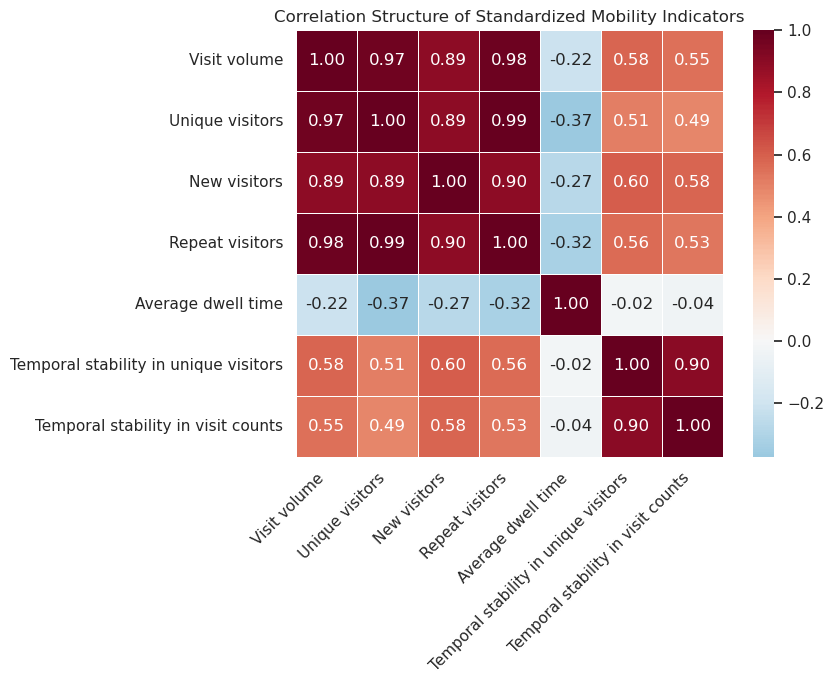

In [ ]:
# ============================================================
# SECTION 3.2 — Correlation structure
# ============================================================

corr = gdf[mobility_vars].corr()
corr_labeled = corr.rename(index=mobility_labels, columns=mobility_labels)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_labeled,
    annot=True,
    cmap="RdBu_r",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
)
plt.title("Correlation Structure of Standardized Mobility Indicators")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The correlation structure revealed that the mobility indicators were neither independent nor interchangeable. Several activity-related variables moved together, while dwell time and temporal stability contributed distinct behavioral information. This pattern justified testing whether a dominant latent dimension organized the broader system.

### 3.3 Evidence of a dominant latent dimension

We then evaluated whether the seven standardized indicators exhibited a dominant common dimension. Because the shared GeoPackage already stored the indicators in standardized form, we estimated principal component analysis directly on those fields.

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.6143,0.6143
1,PC2,0.2281,0.8424
2,PC3,0.1202,0.9626
3,PC4,0.0178,0.9804
4,PC5,0.0173,0.9977
5,PC6,0.0016,0.9993
6,PC7,0.0007,1.0000


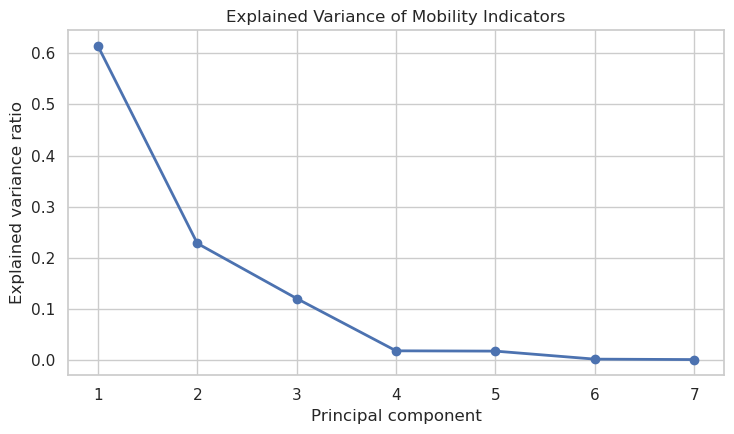

In [ ]:
# ============================================================
# SECTION 3.3 — Principal component analysis
# ============================================================

X_pca = gdf[mobility_vars].dropna().copy()

pca = PCA()
pca.fit(X_pca.values)

explained_variance_df = pd.DataFrame(
    {
        "component": [f"PC{i}" for i in range(1, len(mobility_vars) + 1)],
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
).round(4)

display(explained_variance_df)

plt.figure(figsize=(7.5, 4.5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
    linewidth=2,
)
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Explained Variance of Mobility Indicators")
plt.tight_layout()
plt.show()

The PCA results showed whether the mobility indicators were governed by a dominant shared dimension or instead dispersed across multiple unrelated components. A concentrated first component would support the interpretation of mobility as a structured latent field rather than as traffic volume alone.

### 3.4 Interpreting the first principal component

To understand what the dominant component represented, we examined the loadings of the first principal component. These loadings showed how strongly each mobility indicator contributed to the latent dimension summarized by the MII.

,indicator,column,pc1_loading,absolute_loading
4,Average dwell time,z_dwell_time_mins,-0.1781,0.1781
0,Visit volume,z_log1p_visits_A4,0.3364,0.3364
1,Unique visitors,z_log1p_unique_A4,0.3712,0.3712
3,Repeat visitors,z_log1p_repeat_visitors_A4,0.3818,0.3818
2,New visitors,z_log1p_new_visitors_A4,0.4298,0.4298
6,Temporal stability in visit counts,z_stability_visits_week_cv_A4,0.4365,0.4365
5,Temporal stability in unique visitors,z_stability_unique_week_cv_A4,0.4429,0.4429


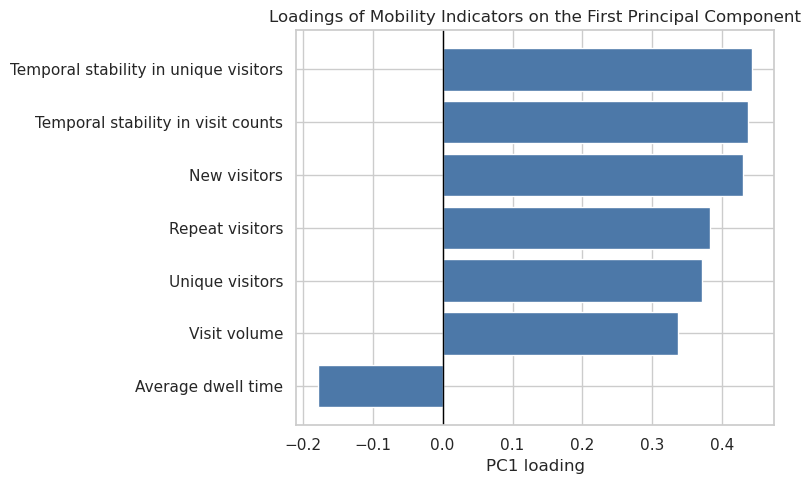

In [ ]:
# ============================================================
# SECTION 3.4 — PC1 loadings
# ============================================================

pc1_loadings_df = pd.DataFrame(
    {
        "indicator": [mobility_labels[var] for var in mobility_vars],
        "column": mobility_vars,
        "pc1_loading": pca.components_[0],
        "absolute_loading": np.abs(pca.components_[0]),
    }
).sort_values("pc1_loading", ascending=True)

display(pc1_loadings_df.round(4))

plt.figure(figsize=(8, 5))
plt.barh(pc1_loadings_df["indicator"], pc1_loadings_df["pc1_loading"], color="#4C78A8")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("PC1 loading")
plt.title("Loadings of Mobility Indicators on the First Principal Component")
plt.tight_layout()
plt.show()

The first principal component captured a coordinated behavioral structure rather than a single raw count variable. In decision terms, this mattered because it suggested that observed movement could be decomposed into recurring access, temporal stability, and visitation structure rather than treated as a single measure of exposure.

### 3.5 Consistency between the recomputed first component and the stored MII

Finally, we verified that the first principal component recomputed from the seven standardized indicators aligned with the **MII** stored in the shared GeoPackage. This step mattered for transparency because it showed that the shared analytical asset preserved the same latent structure used throughout the notebook.

,observations_used,correlation_between_recomputed_pc1_and_stored_mii
0,387779,0.9447


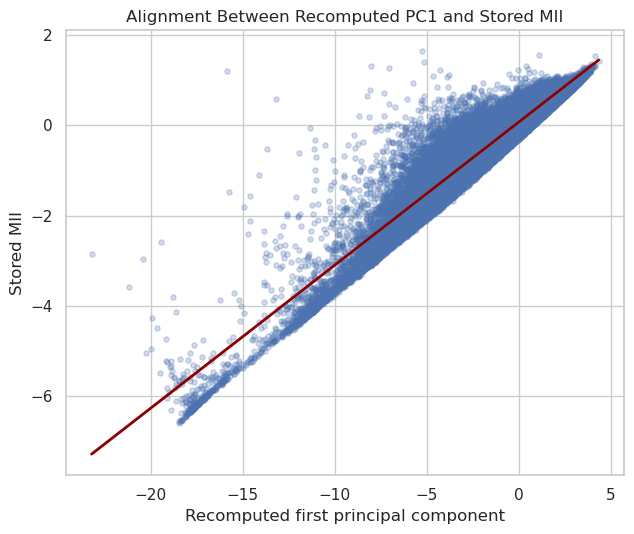

In [ ]:
# ============================================================
# SECTION 3.5 — Consistency check between recomputed PC1 and stored MII
# ============================================================

pc1_scores = pca.transform(X_pca.values)[:, 0]
stored_mii = gdf.loc[X_pca.index, "mii"].values

alignment_df = pd.DataFrame(
    {
        "recomputed_pc1": pc1_scores,
        "stored_mii": stored_mii,
    }
)

alignment_corr = float(
    np.corrcoef(alignment_df["recomputed_pc1"], alignment_df["stored_mii"])[0, 1]
)

alignment_summary = pd.DataFrame(
    [
        {
            "observations_used": len(alignment_df),
            "correlation_between_recomputed_pc1_and_stored_mii": round(alignment_corr, 4),
        }
    ]
)

display(alignment_summary)

plt.figure(figsize=(6.5, 5.5))
sns.regplot(
    data=alignment_df,
    x="recomputed_pc1",
    y="stored_mii",
    scatter_kws={"alpha": 0.25, "s": 14},
    line_kws={"color": "darkred", "linewidth": 2},
)
plt.title("Alignment Between Recomputed PC1 and Stored MII")
plt.xlabel("Recomputed first principal component")
plt.ylabel("Stored MII")
plt.tight_layout()
plt.show()

The alignment between the recomputed first component and the stored MII showed that the shared GeoPackage preserved the same dominant latent structure extracted from the mobility indicators. Across **387,779 tracts**, the recomputed component and the stored MII remained strongly aligned (`r = 0.9447`), indicating that the shared analytical asset faithfully retained the behavioral structure used throughout the workflow. This mattered for decision-making because it showed that raw traffic volume could be transformed into a more informative behavioral signal, rather than treated as a single proxy for local opportunity.

In the next section, we moved from a national latent structure to spatially varying covariance patterns and recovered geographically differentiated mobility infrastructure regimes.

# 4. Spatial Regime Discovery

The national latent structure identified in the previous section did not imply that mobility behavior was organized uniformly across space. Instead, the notebook’s central argument was that the covariance structure of mobility could vary geographically, revealing distinct spatial environments that would remain hidden under a single national decomposition.

To recover this spatial heterogeneity, we estimated localized covariance signatures from the same seven standardized mobility indicators used to construct the MII. We then discretized those localized signatures into a finite set of **mobility infrastructure regimes**.

This step mattered because places could differ not only in the overall level of mobility-based infrastructure, but also in the **way mobility behavior was organized locally**. Regime discovery moved the analysis beyond a single national latent dimension and toward a spatially differentiated view of mobility-based infrastructure.

In [ ]:
# ============================================================
# SECTION 4 — Imports and configuration
# ============================================================

# If needed in a clean environment, uncomment the next line:
# %pip install -q scikit-learn

from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

regime_vars = mobility_vars.copy()

metric_crs = 5880
target_focal_locations = 25000
k_neighbors = 200
n_regimes = 4
random_state = 42

### 4.1 Preparing the localized regime workflow

To keep the notebook fully runnable while preserving national coverage, we estimated localized covariance signatures at systematically distributed focal locations and then propagated the resulting regime labels to the nearest valid tract centroids.

This approach preserved the framework's substantive logic while making the spatial regime step computationally tractable in notebook form.

In [ ]:
# ============================================================
# SECTION 4.1 — Prepare valid tract-level inputs in metric space
# ============================================================

gdf_metric = gdf.to_crs(epsg=metric_crs).copy()

gdf_regime_valid = gdf_metric.dropna(subset=regime_vars).copy()
gdf_regime_valid["centroid"] = gdf_regime_valid.geometry.centroid

coords_valid = np.column_stack(
    [
        gdf_regime_valid["centroid"].x.values,
        gdf_regime_valid["centroid"].y.values,
    ]
)

X_valid = gdf_regime_valid[regime_vars].to_numpy()

regime_prep_summary = pd.DataFrame(
    [
        {
            "total_tracts": len(gdf_metric),
            "valid_tracts_for_regime_analysis": len(gdf_regime_valid),
            "excluded_due_to_missing_regime_fields": len(gdf_metric) - len(gdf_regime_valid),
            "metric_crs": f"EPSG:{metric_crs}",
            "k_neighbors": k_neighbors,
            "target_focal_locations": target_focal_locations,
            "n_regimes": n_regimes,
        }
    ]
)

display(regime_prep_summary)

,total_tracts,valid_tracts_for_regime_analysis,excluded_due_to_missing_regime_fields,metric_crs,k_neighbors,target_focal_locations,n_regimes
0,387779,387779,0,EPSG:5880,200,25000,4


In [ ]:
# ============================================================
# SECTION 4.1 — Select systematically distributed focal locations
# ============================================================

def select_focal_locations(coords: np.ndarray, target_n: int) -> np.ndarray:
    """
    Select spatially distributed focal locations using deterministic grid thinning.
    """
    if len(coords) <= target_n:
        return np.arange(len(coords))

    x = coords[:, 0]
    y = coords[:, 1]

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    width = max(xmax - xmin, 1.0)
    height = max(ymax - ymin, 1.0)

    cell_size = np.sqrt((width * height) / target_n)
    cell_size = max(cell_size, 1.0)

    cell_x = np.floor((x - xmin) / cell_size).astype(np.int64)
    cell_y = np.floor((y - ymin) / cell_size).astype(np.int64)

    cell_df = pd.DataFrame({"cell_x": cell_x, "cell_y": cell_y})
    focal_idx = cell_df.drop_duplicates().index.to_numpy()

    if len(focal_idx) > target_n:
        focal_idx = focal_idx[np.linspace(0, len(focal_idx) - 1, target_n, dtype=int)]

    return np.sort(focal_idx)


focal_idx = select_focal_locations(coords_valid, target_focal_locations)
coords_focal = coords_valid[focal_idx]

focal_summary = pd.DataFrame(
    [
        {
            "candidate_valid_tracts": len(coords_valid),
            "target_focal_locations": target_focal_locations,
            "selected_focal_locations": len(focal_idx),
            "k_neighbors": k_neighbors,
            "n_regimes": n_regimes,
        }
    ]
)

display(focal_summary)

,candidate_valid_tracts,target_focal_locations,selected_focal_locations,k_neighbors,n_regimes
0,387779,25000,7260,200,4


### 4.2 Localized covariance signatures

For each focal location, we identified a local neighborhood of nearby tracts and estimated a two-component PCA on the seven standardized mobility indicators. We then represented each focal location by:

- the local share of variance explained by the first two components, and
- the focal tract’s score on those two localized components.

Together, these quantities summarized how mobility behavior was organized in the focal neighborhood.

In [ ]:
# ============================================================
# SECTION 4.2 — Estimate localized PCA signatures
# ============================================================

nn_all = NearestNeighbors(
    n_neighbors=k_neighbors,
    algorithm="ball_tree",
)
nn_all.fit(coords_valid)

_, neighbor_indices = nn_all.kneighbors(coords_focal)

global_pc1_vector = np.asarray(pca.components_[0])
global_pc2_vector = np.asarray(pca.components_[1])

local_signature_rows = []

for focal_position, tract_idx in enumerate(focal_idx):
    local_idx = neighbor_indices[focal_position]
    X_local = X_valid[local_idx]

    local_pca = PCA(n_components=2)
    local_pca.fit(X_local)

    local_pc1 = local_pca.components_[0].copy()
    local_pc2 = local_pca.components_[1].copy()

    if np.dot(local_pc1, global_pc1_vector) < 0:
        local_pc1 *= -1

    if np.dot(local_pc2, global_pc2_vector) < 0:
        local_pc2 *= -1

    focal_values = X_valid[tract_idx].reshape(1, -1)
    local_scores = local_pca.transform(focal_values)[0]

    local_signature_rows.append(
        {
            "ct_id": gdf_regime_valid.iloc[tract_idx]["ct_id"],
            "focal_pc1_score": float(local_scores[0]),
            "focal_pc2_score": float(local_scores[1]),
            "pc1_share": float(local_pca.explained_variance_ratio_[0]),
            "pc2_share": float(local_pca.explained_variance_ratio_[1]),
        }
    )

focal_signatures = pd.DataFrame(local_signature_rows)

signature_summary = pd.DataFrame(
    [
        {
            "successful_local_pca_fits": len(focal_signatures),
            "neighbors_per_focal_location": k_neighbors,
            "selected_focal_locations": len(focal_idx),
        }
    ]
)

display(signature_summary)
display(focal_signatures.head())

,successful_local_pca_fits,neighbors_per_focal_location,selected_focal_locations
0,7260,200,7260


,ct_id,focal_pc1_score,focal_pc2_score,pc1_share,pc2_share
0,110001505000002,1.730301,-0.183745,0.657710,0.186412
1,110001505000011,1.876686,-0.058955,0.656923,0.186505
2,110001505000027,0.147460,0.649069,0.704808,0.153195
3,110001515000002,-1.004254,2.200117,0.729915,0.137851
4,110001525000001,-3.059058,-1.374221,0.587172,0.259836


The localized PCA step produced a spatially varying representation of mobility organization. We next discretized that continuous field into a finite number of interpretable spatial regimes.

### 4.3 Recovering mobility infrastructure regimes

We next grouped localized covariance signatures into a small number of recurring behavioral environments. This step converted continuous local structure into discrete **mobility infrastructure regimes** that could be interpreted, mapped, and compared across the national territory.

In [ ]:
# ============================================================
# SECTION 4.3 — Cluster localized signatures into regimes
# ============================================================

cluster_features = focal_signatures[["focal_pc1_score", "focal_pc2_score"]].to_numpy()

kmeans = KMeans(
    n_clusters=n_regimes,
    n_init=20,
    random_state=random_state,
)

raw_regimes = kmeans.fit_predict(cluster_features)
focal_signatures["raw_regime"] = raw_regimes

regime_order = (
    focal_signatures.groupby("raw_regime")["pc1_share"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

regime_mapping = {old_label: new_label for new_label, old_label in enumerate(regime_order, start=1)}
focal_signatures["infrastructure_regime"] = focal_signatures["raw_regime"].map(regime_mapping)

regime_counts = (
    focal_signatures["infrastructure_regime"]
    .value_counts()
    .sort_index()
    .rename_axis("infrastructure_regime")
    .reset_index(name="n_focal_locations")
)

display(regime_counts)

,infrastructure_regime,n_focal_locations
0,1,245
1,2,948
2,3,1429
3,4,4638


### 4.4 Propagating regime labels to valid census tracts

Because the localized covariance structure was estimated at focal locations, we next propagated the resulting regime labels to the nearest valid census tract centroids. This yielded a tract-level regime layer that preserved national coverage for all tracts with complete mobility information.

In [ ]:
# ============================================================
# SECTION 4.4 — Assign each valid tract to its nearest focal regime
# ============================================================

nn_focal = NearestNeighbors(n_neighbors=1, algorithm="ball_tree")
nn_focal.fit(coords_focal)

_, nearest_focal_idx = nn_focal.kneighbors(coords_valid)
nearest_focal_idx = nearest_focal_idx.flatten()

gdf_regime_valid["focal_pc1_score"] = focal_signatures.iloc[nearest_focal_idx]["focal_pc1_score"].to_numpy()
gdf_regime_valid["focal_pc2_score"] = focal_signatures.iloc[nearest_focal_idx]["focal_pc2_score"].to_numpy()
gdf_regime_valid["pc1_share_local"] = focal_signatures.iloc[nearest_focal_idx]["pc1_share"].to_numpy()
gdf_regime_valid["pc2_share_local"] = focal_signatures.iloc[nearest_focal_idx]["pc2_share"].to_numpy()
gdf_regime_valid["infrastructure_regime"] = focal_signatures.iloc[nearest_focal_idx]["infrastructure_regime"].to_numpy()

regime_output_columns = [
    "ct_id",
    "focal_pc1_score",
    "focal_pc2_score",
    "pc1_share_local",
    "pc2_share_local",
    "infrastructure_regime",
]

gdf = gdf.drop(
    columns=[
        col for col in regime_output_columns[1:]
        if col in gdf.columns
    ],
    errors="ignore",
)

gdf = gdf.merge(
    gdf_regime_valid[regime_output_columns],
    on="ct_id",
    how="left",
)

tract_regime_counts = (
    gdf["infrastructure_regime"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("infrastructure_regime")
    .reset_index(name="n_census_tracts")
)

display(tract_regime_counts)

,infrastructure_regime,n_census_tracts
0,1,1931
1,2,28263
2,3,59295
3,4,298290


### 4.5 Structural profiles of the recovered regimes

After assigning tract-level regime labels, we summarized the average mobility profile associated with each regime. This step allowed us to compare how the seven standardized mobility indicators differed across localized covariance environments.

In [ ]:
# ============================================================
# SECTION 4.5 — Structural profiles of the recovered regimes
# ============================================================

regime_profile = (
    gdf.dropna(subset=["infrastructure_regime"])
    .groupby("infrastructure_regime")[regime_vars]
    .mean()
    .rename(columns=mobility_labels)
    .round(3)
    .reset_index()
)

display(regime_profile)

regime_signature_summary = (
    gdf.dropna(subset=["infrastructure_regime"])
    .groupby("infrastructure_regime")[["pc1_share_local", "pc2_share_local", "focal_pc1_score", "focal_pc2_score"]]
    .mean()
    .round(3)
    .reset_index()
)

display(regime_signature_summary)

,infrastructure_regime,Visit volume,Unique visitors,New visitors,Repeat visitors,Average dwell time,Temporal stability in unique visitors,Temporal stability in visit counts
0,1,-0.687,-0.759,-1.026,-0.829,0.460,-1.862,-1.853
1,2,-0.024,-0.055,-0.085,-0.054,0.144,-0.097,-0.102
2,3,0.247,0.290,0.231,0.271,-0.125,0.008,0.009
3,4,0.129,0.107,0.101,0.111,0.022,0.044,0.042


,infrastructure_regime,pc1_share_local,pc2_share_local,focal_pc1_score,focal_pc2_score
0,1,0.710,0.170,-15.194,-0.154
1,2,0.691,0.212,-1.503,1.564
2,3,0.707,0.200,-2.560,0.051
3,4,0.651,0.240,0.322,-0.173


The recovered regimes differed not only in overall mobility intensity but also in the configuration of recurrence, duration, and temporal regularity. The resulting structure was not evenly distributed across space: some regimes represented relatively specific mobility environments, while others accounted for a much larger share of the national tract system. This distinction remained central to the framework because mobility-based infrastructure varied not only in magnitude but also in local behavioral organization.

### 4.6 National distribution of mobility infrastructure regimes

We finally mapped the tract-level regime assignments to examine whether localized covariance environments were spatially structured across the national territory.

/var/tmp/ipykernel_59146/3225884467.py:26: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf_plot.plot(


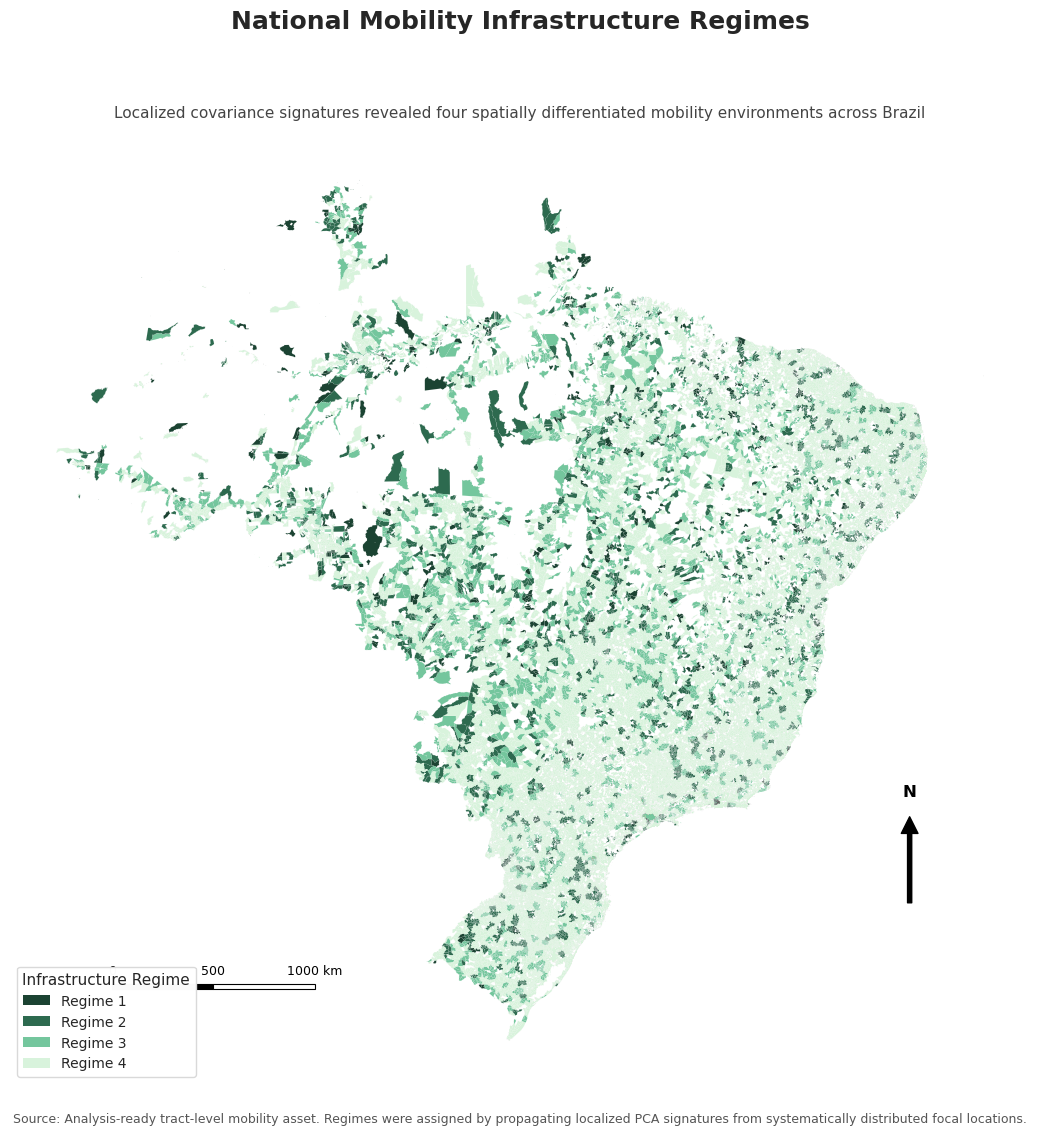

In [ ]:
# ============================================================
# SECTION 4.6 — Map the national regime distribution
# Top-tier cartographic version
# ============================================================

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Reproject to a metric CRS for better cartographic control
plot_crs = "EPSG:5880"

gdf_plot = gdf.dropna(subset=["infrastructure_regime"]).copy()
gdf_plot["infrastructure_regime"] = gdf_plot["infrastructure_regime"].astype(int)
gdf_plot = gdf_plot.to_crs(plot_crs)

# Ordered palette for four regimes
regime_palette = {
    1: "#1b4332",  # deep green
    2: "#2d6a4f",  # green
    3: "#74c69d",  # soft green
    4: "#d8f3dc",  # pale green
}

fig, ax = plt.subplots(figsize=(13.5, 12), facecolor="white")

gdf_plot.plot(
    column="infrastructure_regime",
    categorical=True,
    cmap=None,
    color=gdf_plot["infrastructure_regime"].map(regime_palette),
    linewidth=0.03,
    edgecolor="#f7f7f7",
    ax=ax,
)

# Clean frame
ax.set_axis_off()

# Title and subtitle
fig.suptitle(
    "National Mobility Infrastructure Regimes",
    fontsize=18,
    fontweight="bold",
    y=0.96,
)

ax.set_title(
    "Localized covariance signatures revealed four spatially differentiated mobility environments across Brazil",
    fontsize=11,
    color="#444444",
    pad=14,
)

# Build a cleaner legend
legend_handles = [
    mpatches.Patch(facecolor=regime_palette[i], edgecolor="none", label=f"Regime {i}")
    for i in sorted(regime_palette)
]

legend = ax.legend(
    handles=legend_handles,
    title="Infrastructure Regime",
    loc="lower left",
    frameon=True,
    framealpha=0.98,
    facecolor="white",
    edgecolor="#d9d9d9",
    fontsize=10,
    title_fontsize=11,
)
legend._legend_box.align = "left"

# Bounds for annotation placement
xmin, ymin, xmax, ymax = gdf_plot.total_bounds
xrange = xmax - xmin
yrange = ymax - ymin

# -----------------------------
# North arrow
# -----------------------------
arrow_x = xmin + 0.92 * xrange
arrow_y = ymin + 0.16 * yrange
arrow_len = 0.10 * yrange

ax.annotate(
    "",
    xy=(arrow_x, arrow_y + arrow_len),
    xytext=(arrow_x, arrow_y),
    arrowprops=dict(facecolor="black", edgecolor="black", width=3, headwidth=12),
)

ax.text(
    arrow_x,
    arrow_y + arrow_len + 0.02 * yrange,
    "N",
    ha="center",
    va="bottom",
    fontsize=12,
    fontweight="bold",
    color="black",
)

# -----------------------------
# Scale bar (500 km)
# -----------------------------
scale_bar_km = 500
scale_bar_m = scale_bar_km * 1000

bar_x = xmin + 0.06 * xrange
bar_y = ymin + 0.06 * yrange
bar_h = 0.006 * yrange

ax.add_patch(
    mpatches.Rectangle(
        (bar_x, bar_y),
        scale_bar_m,
        bar_h,
        facecolor="black",
        edgecolor="black",
        linewidth=0.8,
    )
)

ax.add_patch(
    mpatches.Rectangle(
        (bar_x + scale_bar_m, bar_y),
        scale_bar_m,
        bar_h,
        facecolor="white",
        edgecolor="black",
        linewidth=0.8,
    )
)

ax.text(
    bar_x,
    bar_y + 2.2 * bar_h,
    "0",
    ha="center",
    va="bottom",
    fontsize=9,
    color="black",
)

ax.text(
    bar_x + scale_bar_m,
    bar_y + 2.2 * bar_h,
    f"{scale_bar_km}",
    ha="center",
    va="bottom",
    fontsize=9,
    color="black",
)

ax.text(
    bar_x + 2 * scale_bar_m,
    bar_y + 2.2 * bar_h,
    f"{2 * scale_bar_km} km",
    ha="center",
    va="bottom",
    fontsize=9,
    color="black",
)

# Footnote
fig.text(
    0.5,
    0.035,
    "Source: Analysis-ready tract-level mobility asset. Regimes were assigned by propagating localized PCA signatures from systematically distributed focal locations.",
    ha="center",
    va="center",
    fontsize=9,
    color="#555555",
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.show()

The national regime map showed that mobility-based infrastructure was not organized as a single homogeneous field. Instead, the localized covariance structure of mobility behavior formed spatially differentiated environments across the national territory. This mattered operationally because places with similar apparent activity could still belong to distinct structural contexts, and those differences affected how location potential should be interpreted across space.

In the next section, we asked whether those recovered mobility environments also corresponded to different economic contexts using VIIRS nighttime light intensity as an external benchmark.

# 5. External Economic Validation

The mobility infrastructure regimes identified in the previous section were not intended to remain purely behavioral categories. In this section, we evaluated whether those regimes also corresponded to distinct economic environments.

To do so, we used **VIIRS nighttime light intensity** as an external proxy for local economic intensity. We first extracted tract-level nighttime light values from the annual VIIRS archive and then compared their distribution across mobility infrastructure regimes. We next estimated **regime-specific mobility-economic response profiles**, allowing the association between mobility intensity and local economic intensity to vary across localized covariance environments.

This step was important because it moved the framework from structural differentiation alone to **external economic validation**.

In [ ]:
# ============================================================
# SECTION 5 — Imports and configuration
# ============================================================

# If needed in a clean environment, uncomment the next line:
# %pip install -q rasterstats patsy scikit-learn shapely

from rasterstats import zonal_stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer

nightlight_field = "nightlight_mean"
mobility_intensity_var = "z_log1p_visits_A4"
response_random_state = 42

### 5.1 Preparing tract-level nighttime light extraction

We treated annual nighttime light intensity as an external economic benchmark rather than as an input for constructing the MII. This distinction mattered because the goal of this section was not to redefine mobility infrastructure, but to test whether the mobility-based structures recovered earlier also corresponded to systematically different economic environments.

In [ ]:
# ============================================================
# SECTION 5.1 — Prepare GeoDataFrame for VIIRS extraction
# ============================================================

if "gdf" not in globals():
    raise RuntimeError("GeoDataFrame 'gdf' is not available. Run the earlier sections first.")

if "viirs_tiles" not in globals():
    raise RuntimeError("VIIRS tiles are not available. Run Section 2 first.")

gdf_viirs = gdf.to_crs(epsg=4326).copy()

viirs_prep_summary = pd.DataFrame(
    [
        {
            "tracts_available": len(gdf_viirs),
            "tract_crs_for_extraction": str(gdf_viirs.crs),
            "viirs_tile_count": len(viirs_tiles),
            "nightlight_field": nightlight_field,
        }
    ]
)

display(viirs_prep_summary)

,tracts_available,tract_crs_for_extraction,viirs_tile_count,nightlight_field
0,387779,EPSG:4326,30,nightlight_mean


### 5.2 Extracting tract-level nighttime light intensity

Instead of constructing a full national raster mosaic in memory, we processed the VIIRS archive tile-by-tile. For each tile, we identified the census tracts that intersected its extent, computed zonal statistics locally, and aggregated tract-level results across tiles.

This design reduced memory pressure while preserving full national coverage for the validation step.

In [ ]:
# ============================================================
# SECTION 5.2 — Tile-by-tile VIIRS extraction
# ============================================================

from shapely.geometry import box

if "gdf_viirs" not in globals():
    raise RuntimeError("GeoDataFrame 'gdf_viirs' is not available. Run the Section 5 setup cells first.")

if "viirs_tiles" not in globals():
    raise RuntimeError("VIIRS tiles are not available. Run Section 2 first.")

if len(viirs_tiles) == 0:
    raise RuntimeError("No VIIRS tiles were found in the staged archive.")

if nightlight_field in gdf_viirs.columns and gdf_viirs[nightlight_field].notna().any():
    extraction_mode = "reused_existing_field"
else:
    gdf_viirs = gdf_viirs.copy()
    gdf_viirs[nightlight_field] = np.nan
    extraction_mode = "computed_from_viirs_tiles"

    for tile_path in viirs_tiles:
        with rasterio.open(tile_path) as src:
            tile_bounds = src.bounds
            tile_bbox = box(
                tile_bounds.left,
                tile_bounds.bottom,
                tile_bounds.right,
                tile_bounds.top,
            )

            intersects_tile = gdf_viirs.geometry.intersects(tile_bbox)
            gdf_tile = gdf_viirs.loc[intersects_tile].copy()

            if gdf_tile.empty:
                continue

            stats = zonal_stats(
                vectors=gdf_tile.geometry,
                raster=tile_path,
                stats=["mean"],
                nodata=src.nodata,
                geojson_out=False,
            )

            tile_means = pd.Series(
                [row["mean"] for row in stats],
                index=gdf_tile.index,
                dtype="float64",
            )

            existing_values = gdf_viirs.loc[gdf_tile.index, nightlight_field]
            gdf_viirs.loc[gdf_tile.index, nightlight_field] = existing_values.combine_first(tile_means)

if nightlight_field in gdf.columns:
    gdf = gdf.drop(columns=[nightlight_field])

gdf = gdf.merge(
    gdf_viirs[["ct_id", nightlight_field]],
    on="ct_id",
    how="left",
)

nightlight_extraction_summary = pd.DataFrame(
    [
        {
            "extraction_mode": extraction_mode,
            "tiles_available": len(viirs_tiles),
            "tracts_with_nonmissing_nightlight": int(gdf[nightlight_field].notna().sum()),
            "tracts_with_missing_nightlight": int(gdf[nightlight_field].isna().sum()),
            "share_nonmissing": round(float(gdf[nightlight_field].notna().mean()), 4),
        }
    ]
)

display(nightlight_extraction_summary)

/jet/home/rpereir2/.local/lib/python3.12/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


,extraction_mode,tiles_available,tracts_with_nonmissing_nightlight,tracts_with_missing_nightlight,share_nonmissing
0,computed_from_viirs_tiles,30,220195,167584,0.5678


The extraction produced tract-level estimates of nighttime light intensity that could be linked directly to the recovered mobility infrastructure regimes. We next inspected the overall distribution of this external economic proxy before comparing it across regimes.

In [ ]:
# ============================================================
# SECTION 5.2 — Distribution of extracted nightlight values
# ============================================================

nightlight_valid = gdf[nightlight_field].dropna()

nightlight_summary = pd.DataFrame(
    [
        {
            "count": int(nightlight_valid.shape[0]),
            "mean": round(float(nightlight_valid.mean()), 4),
            "median": round(float(nightlight_valid.median()), 4),
            "min": round(float(nightlight_valid.min()), 4),
            "max": round(float(nightlight_valid.max()), 4),
        }
    ]
)

display(nightlight_summary)

,count,mean,median,min,max
0,220195,18.4824,11.4053,0.0,229.5716


### 5.3 Economic differentiation across mobility infrastructure regimes

We then compared nighttime light intensity across the recovered mobility infrastructure regimes. If those regimes captured substantively different mobility environments, they should also correspond to systematically different levels of local economic intensity.

In [ ]:
# ============================================================
# SECTION 5.3 — Regime-level economic profiles
# ============================================================

validation_df = gdf.dropna(subset=["infrastructure_regime", nightlight_field]).copy()
validation_df["infrastructure_regime"] = validation_df["infrastructure_regime"].astype(int)

regime_nightlight_summary = (
    validation_df.groupby("infrastructure_regime")[nightlight_field]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
    .reset_index()
)

display(regime_nightlight_summary)

,infrastructure_regime,count,mean,median,min,max
0,1,1519,5.5824,0.5506,0.0,104.4702
1,2,17139,15.1592,6.8125,0.0,141.5237
2,3,26229,21.5319,11.8406,0.0,193.8116
3,4,175308,18.4629,11.9762,0.0,229.5716


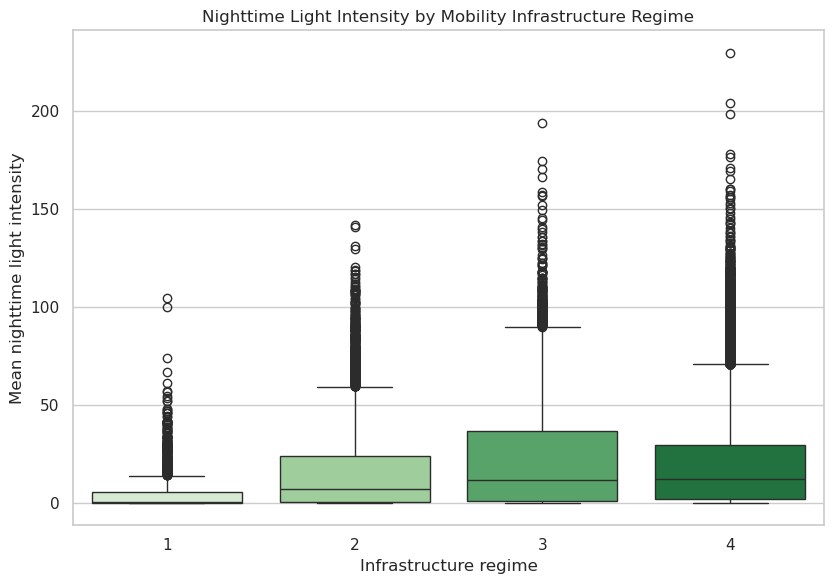

In [ ]:
# ============================================================
# SECTION 5.3 — Boxplot of nighttime light intensity by regime
# ============================================================

plt.figure(figsize=(8.5, 6))
sns.boxplot(
    data=validation_df,
    x="infrastructure_regime",
    y=nightlight_field,
    palette="Greens",
)
plt.title("Nighttime Light Intensity by Mobility Infrastructure Regime")
plt.xlabel("Infrastructure regime")
plt.ylabel("Mean nighttime light intensity")
plt.tight_layout()
plt.show()

The regime comparison showed that the spatial environments recovered from mobility behavior also differed economically. This was substantively important because it showed that similar levels of apparent activity did not imply similar economic context once the underlying mobility structure of places was taken into account.

### 5.4 Regime-specific mobility-economic response profiles

The economic validation step did not stop at comparing average nighttime luminosity across regimes. It also evaluated whether the relationship between **mobility intensity** and **local economic intensity** varied across regimes.

To remain consistent with the conceptual definition used throughout the notebook, we represented **mobility intensity** with the standardized log-transformed visit-volume measure `z_log1p_visits_A4`. We then estimated regime-specific spline response functions, allowing the geometry of the mobility-economic relationship to differ across localized covariance environments.

In [ ]:
# ============================================================
# SECTION 5.4 — Helper function for spline-based response estimation
# ============================================================

def fit_regime_spline(x: np.ndarray, y: np.ndarray, n_knots: int = 5, degree: int = 3):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y)

    spline = SplineTransformer(
        degree=degree,
        n_knots=n_knots,
        include_bias=False,
    )
    X_spline = spline.fit_transform(x)

    model = LinearRegression()
    model.fit(X_spline, y)

    x_grid = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
    y_pred = model.predict(spline.transform(x_grid))

    r2 = model.score(X_spline, y)

    return {
        "model": model,
        "spline": spline,
        "x_grid": x_grid.flatten(),
        "y_pred": y_pred,
        "r2": float(r2),
        "n_obs": int(len(y)),
        "x_min": float(x.min()),
        "x_max": float(x.max()),
    }

In [ ]:
# ============================================================
# SECTION 5.4 — Estimate regime-specific response curves
# ============================================================

response_df = gdf.dropna(
    subset=["infrastructure_regime", mobility_intensity_var, nightlight_field]
).copy()
response_df["infrastructure_regime"] = response_df["infrastructure_regime"].astype(int)

regime_models = {}
regime_diagnostics = []

for regime_id in sorted(response_df["infrastructure_regime"].unique()):
    regime_subset = response_df.loc[response_df["infrastructure_regime"] == regime_id]

    model_result = fit_regime_spline(
        x=regime_subset[mobility_intensity_var].values,
        y=regime_subset[nightlight_field].values,
        n_knots=5,
        degree=3,
    )

    regime_models[regime_id] = model_result

    regime_diagnostics.append(
        {
            "regime": regime_id,
            "n_obs": model_result["n_obs"],
            "x_min": round(model_result["x_min"], 3),
            "x_max": round(model_result["x_max"], 3),
            "r2": round(model_result["r2"], 4),
        }
    )

regime_diagnostics_df = pd.DataFrame(regime_diagnostics)
display(regime_diagnostics_df)

,regime,n_obs,x_min,x_max,r2
0,1,1519,-3.907,1.350,0.3694
1,2,17139,-3.610,1.946,0.3952
2,3,26229,-3.653,2.379,0.5677
3,4,175308,-3.835,2.618,0.4047


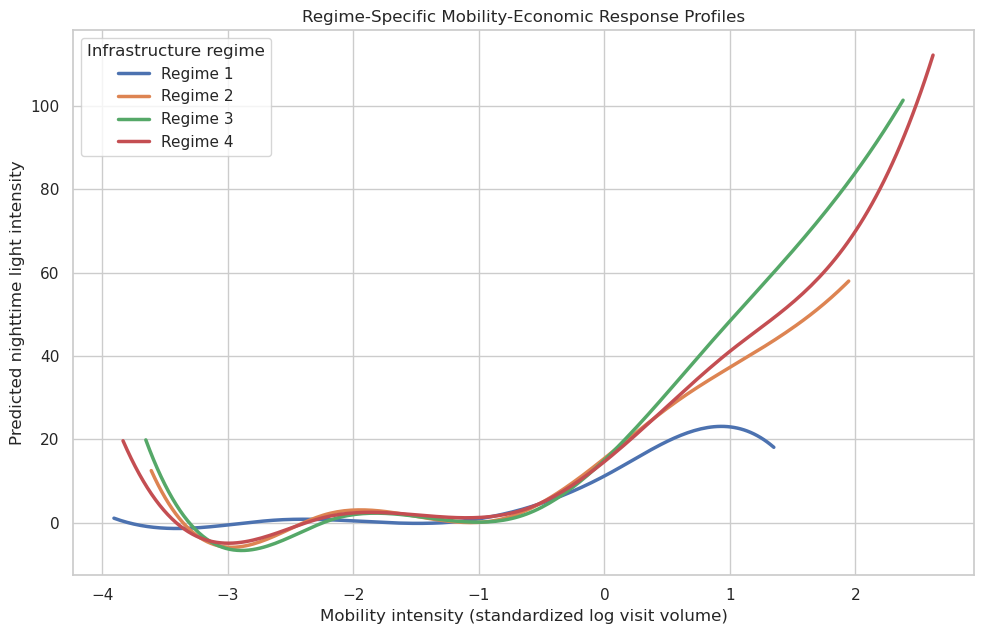

In [ ]:
# ============================================================
# SECTION 5.4 — Plot regime-specific mobility-economic response curves
# ============================================================

plt.figure(figsize=(10, 6.5))

for regime_id, model_result in regime_models.items():
    plt.plot(
        model_result["x_grid"],
        model_result["y_pred"],
        linewidth=2.5,
        label=f"Regime {regime_id}",
    )

plt.title("Regime-Specific Mobility-Economic Response Profiles")
plt.xlabel("Mobility intensity (standardized log visit volume)")
plt.ylabel("Predicted nighttime light intensity")
plt.legend(title="Infrastructure regime")
plt.tight_layout()
plt.show()

The response curves showed that the economic meaning of mobility intensity changed across structurally distinct mobility environments. In other words, similar levels of mobility intensity aligned differently with local economic intensity depending on the regime in which they occurred.

Taken together, the validation results showed that the recovered regimes were not merely statistical partitions of mobility covariance structure. They also corresponded to distinct economic environments and distinct mobility-economic response profiles.

In the next section, we moved from tract-level structure to multiscale reconstruction and showed how mass-preserving downscaling revealed sub-tract variation that tract-level representation still concealed.

# 6. Multiscale Reconstruction

The previous sections showed that mobility-based infrastructure formed a spatially differentiated field across the national territory. Yet tract-level analysis still left an important question open: how much variation remained hidden **within** those administrative units?

To address that question, we implemented a **mass-preserving downscaling** exercise within the São Paulo metropolitan area. The goal was not to change tract-level values, but to redistribute them across a fine spatial grid while preserving aggregate tract-level consistency.

This step mattered because tract averages could still conceal meaningful internal differentiation. For applied spatial targeting, that meant a tract-level signal might identify broad opportunity structure while still missing where local concentration and attenuation actually occurred within the tract.

In [ ]:
# ============================================================
# SECTION 6 — Imports and configuration
# ============================================================

from contextlib import ExitStack

from shapely.geometry import box
from rasterio.features import rasterize
from rasterio.merge import merge
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling
from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

sp_bbox = (-47.25, -24.20, -45.70, -23.10)
grid_resolution_m = 100
focus_buffer_m = 4000
downscale_plot_crs = "EPSG:5880"

### 6.1 Selecting the metropolitan study area

For the downscaling exercise, we focused on a São Paulo metropolitan window that captured a dense and heterogeneous urban environment suitable for evaluating intra-tract variation. We preserved the tract-level analytical fields from the national GeoPackage and prepared the selected tracts in both geographic and metric coordinate systems.

In [ ]:
# ============================================================
# SECTION 6.1 — Select São Paulo metropolitan window
# ============================================================

gdf_geo = gdf.to_crs(epsg=4326).copy()

lon_min, lat_min, lon_max, lat_max = sp_bbox
sp_geo = gdf_geo.cx[lon_min:lon_max, lat_min:lat_max].copy()

if sp_geo.empty:
    raise RuntimeError("The Sao Paulo study window returned no census tracts.")

sp_metric = sp_geo.to_crs(downscale_plot_crs).copy()
sp_metric["tract_code"] = np.arange(1, len(sp_metric) + 1)

sp_summary = pd.DataFrame(
    [
        {
            "study_area": "Sao Paulo metropolitan window",
            "bbox_wgs84": str(sp_bbox),
            "selected_tracts": len(sp_geo),
            "geographic_crs": str(sp_geo.crs),
            "metric_crs": downscale_plot_crs,
            "grid_resolution_m": grid_resolution_m,
        }
    ]
)

display(sp_summary)

,study_area,bbox_wgs84,selected_tracts,geographic_crs,metric_crs,grid_resolution_m
0,Sao Paulo metropolitan window,"(-47.25, -24.2, -45.7, -23.1)",52621,EPSG:4326,EPSG:5880,100


### 6.2 Preparing the ancillary VIIRS surface at 100-meter resolution

The downscaling logic used VIIRS nighttime light intensity as the ancillary layer guiding within-tract redistribution. To preserve that logic while keeping the notebook efficient, we selected only the VIIRS tiles intersecting the São Paulo window, merged them locally, and reprojected the resulting luminosity surface to the same 100-meter grid used for downscaling.

In [ ]:
# ============================================================
# SECTION 6.2 — Select VIIRS tiles intersecting the study area
# ============================================================

study_bbox_geom = box(*sp_geo.total_bounds)

intersecting_viirs_tiles = []

for tile_path in viirs_tiles:
    with rasterio.open(tile_path) as src:
        tile_bounds = src.bounds
        tile_geom = box(tile_bounds.left, tile_bounds.bottom, tile_bounds.right, tile_bounds.top)
        if tile_geom.intersects(study_bbox_geom):
            intersecting_viirs_tiles.append(tile_path)

if len(intersecting_viirs_tiles) == 0:
    raise RuntimeError("No VIIRS tiles intersected the Sao Paulo study window.")

viirs_window_summary = pd.DataFrame(
    [
        {
            "intersecting_viirs_tiles": len(intersecting_viirs_tiles),
            "first_tile": intersecting_viirs_tiles[0].name,
        }
    ]
)

display(viirs_window_summary)

,intersecting_viirs_tiles,first_tile
0,1,VIIRS_annual_2024_part_22.tif


In [ ]:
# ============================================================
# SECTION 6.2 — Build 100 m grid and reproject VIIRS
# ============================================================

xmin, ymin, xmax, ymax = sp_metric.total_bounds
width = int(np.ceil((xmax - xmin) / grid_resolution_m))
height = int(np.ceil((ymax - ymin) / grid_resolution_m))
target_transform = from_origin(xmin, ymax, grid_resolution_m, grid_resolution_m)

with ExitStack() as stack:
    src_datasets = [stack.enter_context(rasterio.open(tile)) for tile in intersecting_viirs_tiles]
    merged_viirs, merged_transform = merge(src_datasets)

merged_viirs_band = merged_viirs[0]

viirs_100m = np.full((height, width), np.nan, dtype="float32")

reproject(
    source=merged_viirs_band,
    destination=viirs_100m,
    src_transform=merged_transform,
    src_crs="EPSG:4326",
    dst_transform=target_transform,
    dst_crs=downscale_plot_crs,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

grid_summary = pd.DataFrame(
    [
        {
            "grid_width_cells": width,
            "grid_height_cells": height,
            "grid_total_cells": int(width * height),
            "grid_resolution_m": grid_resolution_m,
            "viirs_nonmissing_cells": int(np.isfinite(viirs_100m).sum()),
        }
    ]
)

display(grid_summary)

,grid_width_cells,grid_height_cells,grid_total_cells,grid_resolution_m,viirs_nonmissing_cells
0,1982,1380,2735160,100,2735160


### 6.3 Mass-preserving tract-to-grid redistribution

We then assigned each 100-meter grid cell to a census tract and redistributed tract-level MII values across the grid using normalized VIIRS-derived weights.

For each tract, the within-tract weights summed to one. This ensured exact mass preservation: the sum of the redistributed cell values within a tract remained equal to the original tract-level MII. When a tract contained no positive ancillary signal, we fell back to a uniform allocation rule within that tract.

In [ ]:
# ============================================================
# SECTION 6.3 — Rasterize tracts and compute mass-preserving allocation
# ============================================================

tract_raster = rasterize(
    shapes=zip(sp_metric.geometry, sp_metric["tract_code"]),
    out_shape=(height, width),
    transform=target_transform,
    fill=0,
    dtype="int32",
)

valid_cell_mask = tract_raster > 0
tract_codes_flat = tract_raster[valid_cell_mask].astype(np.int32)

viirs_weights = np.where(np.isfinite(viirs_100m) & (viirs_100m > 0), viirs_100m, 0.0)
viirs_weights_flat = viirs_weights[valid_cell_mask]

max_code = int(sp_metric["tract_code"].max())
pixel_counts = np.bincount(tract_codes_flat, minlength=max_code + 1)
weight_sums = np.bincount(tract_codes_flat, weights=viirs_weights_flat, minlength=max_code + 1)

mii_by_code = np.zeros(max_code + 1, dtype="float64")
mii_norm_by_code = np.zeros(max_code + 1, dtype="float64")
mii_by_code[sp_metric["tract_code"].values] = sp_metric["mii"].values
mii_norm_by_code[sp_metric["tract_code"].values] = sp_metric["mii_norm"].values

sum_lookup = weight_sums[tract_codes_flat]
count_lookup = pixel_counts[tract_codes_flat]

normalized_weights_flat = np.where(
    sum_lookup > 0,
    viirs_weights_flat / sum_lookup,
    1.0 / np.maximum(count_lookup, 1),
)

mii_100m_flat = mii_by_code[tract_codes_flat] * normalized_weights_flat
mii_norm_100m_flat = mii_norm_by_code[tract_codes_flat] * normalized_weights_flat

mii_100m = np.full((height, width), np.nan, dtype="float64")
mii_norm_100m = np.full((height, width), np.nan, dtype="float64")

mii_100m[valid_cell_mask] = mii_100m_flat
mii_norm_100m[valid_cell_mask] = mii_norm_100m_flat

allocated_sum_by_tract = np.bincount(
    tract_codes_flat,
    weights=mii_100m_flat,
    minlength=max_code + 1,
)

original_sum_by_tract = np.zeros(max_code + 1, dtype="float64")
original_sum_by_tract[sp_metric["tract_code"].values] = sp_metric["mii"].values

mass_check_df = pd.DataFrame(
    {
        "tract_code": sp_metric["tract_code"].values,
        "original_mii": original_sum_by_tract[sp_metric["tract_code"].values],
        "allocated_mii_sum": allocated_sum_by_tract[sp_metric["tract_code"].values],
    }
)

mass_check_df["absolute_difference"] = (
    mass_check_df["allocated_mii_sum"] - mass_check_df["original_mii"]
).abs()

mass_preservation_summary = pd.DataFrame(
    [
        {
            "total_original_mii": round(float(mass_check_df["original_mii"].sum()), 6),
            "total_allocated_mii": round(float(mass_check_df["allocated_mii_sum"].sum()), 6),
            "max_absolute_tract_difference": round(float(mass_check_df["absolute_difference"].max()), 10),
            "mean_absolute_tract_difference": round(float(mass_check_df["absolute_difference"].mean()), 10),
        }
    ]
)

display(mass_preservation_summary)
display(mass_check_df.head())

/var/tmp/ipykernel_5597/791873485.py:33: RuntimeWarning: invalid value encountered in divide
  viirs_weights_flat / sum_lookup,


,total_original_mii,total_allocated_mii,max_absolute_tract_difference,mean_absolute_tract_difference
0,18280.530318,17131.811259,2.750485,0.027372


,tract_code,original_mii,allocated_mii_sum,absolute_difference
0,1,0.317001,0.317001,0.000000e+00
1,2,-0.323996,-0.323996,5.551115e-17
2,3,0.639810,0.639810,0.000000e+00
3,4,0.674441,0.674441,1.110223e-16
4,5,0.425055,0.425055,5.551115e-17


The preservation check verified the core algebraic constraint of the downscaling operator: tract-level values were redistributed across the 100-meter grid without altering tract-level totals. The reconstructed surface represented within-tract redistribution, not the creation of new aggregate mass.

### 6.4 Comparing tract-level structure and the downscaled surface

We next compared the original tract-level infrastructure field with the reconstructed fine-scale surface. The tract map preserved the macro-scale structure of the MII, whereas the 100-meter surface revealed where infrastructure mass concentrated or attenuated relative to a uniform within-tract allocation.

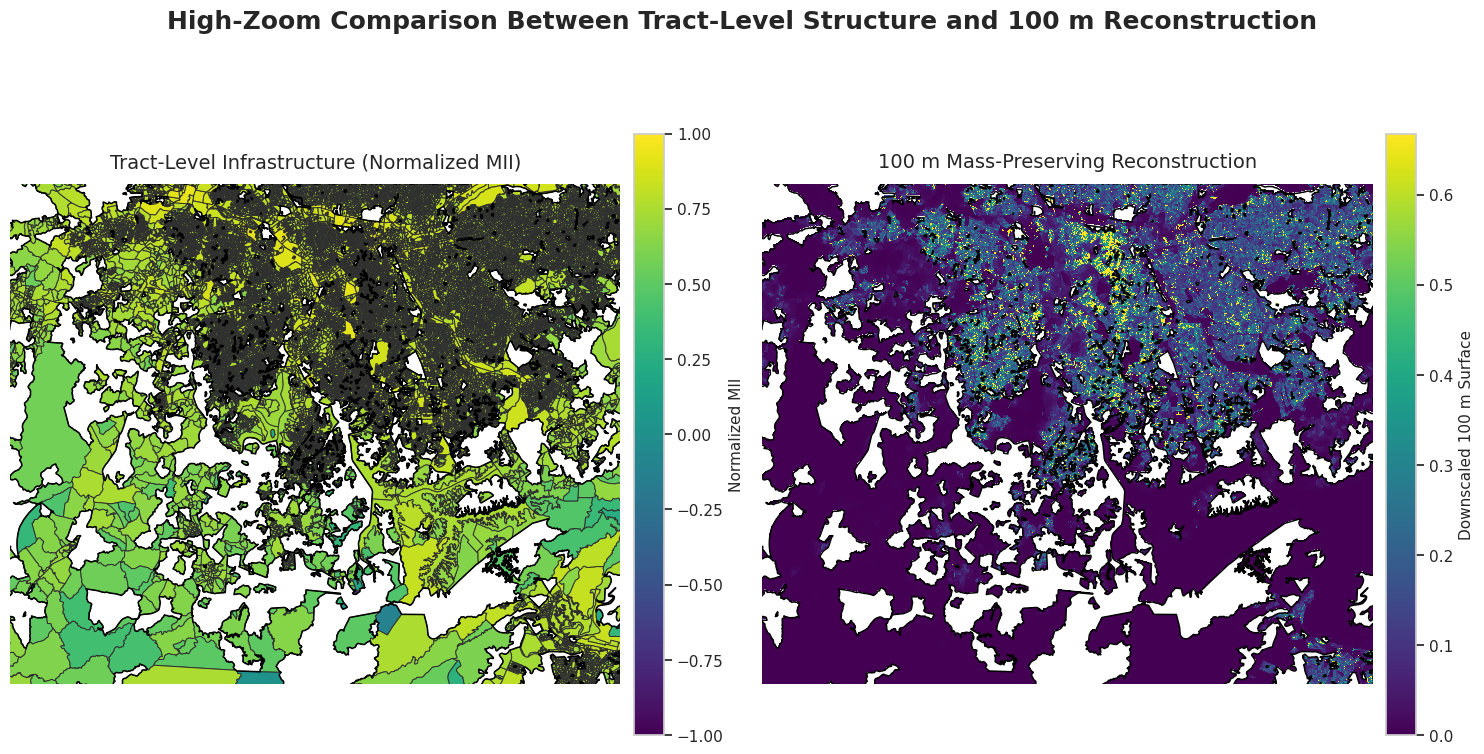

,selected_tracts,left_scale,right_scale_min,right_scale_max
0,34985,"fixed [-1, 1]",0.0,0.6679


In [ ]:
# ============================================================
# SECTION 6.4 — Manual-bbox comparison: tract-level vs 100 m surface
# ============================================================

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ------------------------------------------------------------
# 1. Manual focus window (EDIT HERE IF NEEDED)
# Coordinates in the metric CRS used by sp_metric
# ------------------------------------------------------------
# Initial suggestion: use the current urban core area and fine-tune if needed
fxmin, fymin, fxmax, fymax = (
    xmin + 0.18 * (xmax - xmin),
    ymin + 0.22 * (ymax - ymin),
    xmin + 0.52 * (xmax - xmin),
    ymin + 0.62 * (ymax - ymin),
)

focus_window = box(fxmin, fymin, fxmax, fymax)
sp_focus = sp_metric.loc[sp_metric.geometry.intersects(focus_window)].copy()

if sp_focus.empty:
    raise RuntimeError("The manual bounding box returned no tracts. Adjust fxmin, fymin, fxmax, fymax.")

focus_outline = sp_focus.dissolve()

# ------------------------------------------------------------
# 2. Raster crop for the same bbox
# ------------------------------------------------------------
row_min = max(0, int((ymax - fymax) / grid_resolution_m))
row_max = min(height, int(np.ceil((ymax - fymin) / grid_resolution_m)))
col_min = max(0, int((fxmin - xmin) / grid_resolution_m))
col_max = min(width, int(np.ceil((fxmax - xmin) / grid_resolution_m)))

mii_100m_focus = mii_norm_100m[row_min:row_max, col_min:col_max]

raster_extent = (
    xmin + col_min * grid_resolution_m,
    xmin + col_max * grid_resolution_m,
    ymax - row_max * grid_resolution_m,
    ymax - row_min * grid_resolution_m,
)

raster_values = mii_100m_focus[np.isfinite(mii_100m_focus)]
if raster_values.size == 0:
    raise RuntimeError("The selected bbox produced no valid downscaled raster values. Adjust the bbox.")

# ------------------------------------------------------------
# 3. Color scales
# ------------------------------------------------------------
# Left panel: fixed normalized scale for conceptual consistency
left_vmin, left_vmax = -1.0, 1.0

# Right panel: local stretch to make 100 m variation visible
right_vmin = float(np.nanpercentile(raster_values, 2))
right_vmax = float(np.nanpercentile(raster_values, 98))

if right_vmin == right_vmax:
    right_vmin = float(np.nanmin(raster_values))
    right_vmax = float(np.nanmax(raster_values))

# ------------------------------------------------------------
# 4. Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 8), facecolor="white")

cmap_name = "viridis"

# Left panel — tract polygons
sp_focus.plot(
    column="mii_norm",
    cmap=cmap_name,
    linewidth=0.7,
    edgecolor="#2f2f2f",
    ax=axes[0],
    vmin=left_vmin,
    vmax=left_vmax,
)

focus_outline.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=1.1,
)

axes[0].set_xlim(fxmin, fxmax)
axes[0].set_ylim(fymin, fymax)
axes[0].set_title("Tract-Level Infrastructure (Normalized MII)", fontsize=14, pad=12)
axes[0].set_axis_off()

sm_left = ScalarMappable(
    norm=Normalize(vmin=left_vmin, vmax=left_vmax),
    cmap=cmap_name,
)
sm_left._A = []

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    fraction=0.046,
    pad=0.02,
)
cbar_left.set_label("Normalized MII", fontsize=11)

# Right panel — 100 m raster
axes[1].imshow(
    mii_100m_focus,
    cmap=cmap_name,
    extent=raster_extent,
    origin="upper",
    interpolation="nearest",
    vmin=right_vmin,
    vmax=right_vmax,
)

focus_outline.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=1.1,
)

axes[1].set_xlim(fxmin, fxmax)
axes[1].set_ylim(fymin, fymax)
axes[1].set_title("100 m Mass-Preserving Reconstruction", fontsize=14, pad=12)
axes[1].set_axis_off()

sm_right = ScalarMappable(
    norm=Normalize(vmin=right_vmin, vmax=right_vmax),
    cmap=cmap_name,
)
sm_right._A = []

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    fraction=0.046,
    pad=0.02,
)
cbar_right.set_label("Downscaled 100 m Surface", fontsize=11)

fig.suptitle(
    "High-Zoom Comparison Between Tract-Level Structure and 100 m Reconstruction",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ------------------------------------------------------------
# 5. Optional diagnostic table
# ------------------------------------------------------------
focus_summary = pd.DataFrame(
    [
        {
            "selected_tracts": len(sp_focus),
            "left_scale": "fixed [-1, 1]",
            "right_scale_min": round(right_vmin, 4),
            "right_scale_max": round(right_vmax, 4),
        }
    ]
)

display(focus_summary)

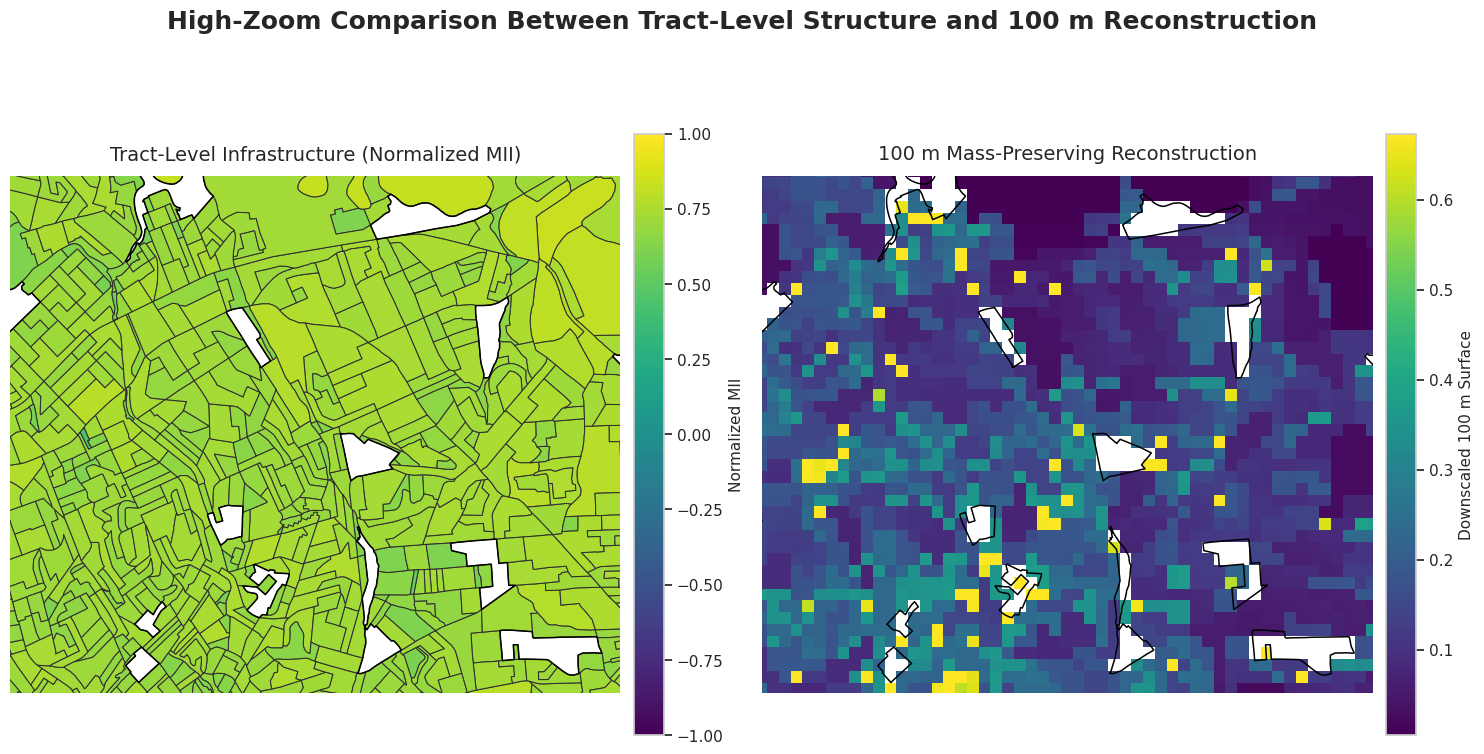

,selected_tracts,bbox_center_x,bbox_center_y,bbox_width_m,bbox_height_m,left_scale,right_scale_min,right_scale_max
0,585,5778907.82,7380062.65,5200,4400,"fixed [-1, 1]",0.0052,0.6734


In [ ]:
# ============================================================
# SECTION 6.4 — Manual zoom-in on the most informative local area
# Reduced zoom version
# ============================================================

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ------------------------------------------------------------
# 1. Manual zoom-in bbox
# Adjust these values if needed
# ------------------------------------------------------------
focus_width = 5200
focus_height = 4400

# Same center as before; larger window for less aggressive zoom
cx = xmin + 0.52 * (xmax - xmin)
cy = ymin + 0.60 * (ymax - ymin)

fxmin = cx - focus_width / 2
fxmax = cx + focus_width / 2
fymin = cy - focus_height / 2
fymax = cy + focus_height / 2

focus_window = box(fxmin, fymin, fxmax, fymax)
sp_focus = sp_metric.loc[sp_metric.geometry.intersects(focus_window)].copy()

if sp_focus.empty:
    raise RuntimeError("The zoom-in bbox returned no tracts. Adjust cx, cy, focus_width, or focus_height.")

focus_outline = sp_focus.dissolve()

# ------------------------------------------------------------
# 2. Raster crop for the same bbox
# ------------------------------------------------------------
row_min = max(0, int((ymax - fymax) / grid_resolution_m))
row_max = min(height, int(np.ceil((ymax - fymin) / grid_resolution_m)))
col_min = max(0, int((fxmin - xmin) / grid_resolution_m))
col_max = min(width, int(np.ceil((fxmax - xmin) / grid_resolution_m)))

mii_100m_focus = mii_norm_100m[row_min:row_max, col_min:col_max]

raster_extent = (
    xmin + col_min * grid_resolution_m,
    xmin + col_max * grid_resolution_m,
    ymax - row_max * grid_resolution_m,
    ymax - row_min * grid_resolution_m,
)

raster_values = mii_100m_focus[np.isfinite(mii_100m_focus)]
if raster_values.size == 0:
    raise RuntimeError("The selected zoom-in bbox produced no valid raster values.")

# ------------------------------------------------------------
# 3. Color scales
# Left: fixed normalized scale
# Right: local stretch to reveal 100 m variation
# ------------------------------------------------------------
left_vmin, left_vmax = -1.0, 1.0

right_vmin = float(np.nanpercentile(raster_values, 2))
right_vmax = float(np.nanpercentile(raster_values, 98))

if right_vmin == right_vmax:
    right_vmin = float(np.nanmin(raster_values))
    right_vmax = float(np.nanmax(raster_values))

# ------------------------------------------------------------
# 4. Figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 8), facecolor="white")

cmap_name = "viridis"

# Left panel — tract polygons
sp_focus.plot(
    column="mii_norm",
    cmap=cmap_name,
    linewidth=0.75,
    edgecolor="#2f2f2f",
    ax=axes[0],
    vmin=left_vmin,
    vmax=left_vmax,
)

focus_outline.boundary.plot(
    ax=axes[0],
    color="black",
    linewidth=1.1,
)

axes[0].set_xlim(fxmin, fxmax)
axes[0].set_ylim(fymin, fymax)
axes[0].set_title("Tract-Level Infrastructure (Normalized MII)", fontsize=14, pad=12)
axes[0].set_axis_off()

sm_left = ScalarMappable(
    norm=Normalize(vmin=left_vmin, vmax=left_vmax),
    cmap=cmap_name,
)
sm_left._A = []

cbar_left = fig.colorbar(
    sm_left,
    ax=axes[0],
    fraction=0.046,
    pad=0.02,
)
cbar_left.set_label("Normalized MII", fontsize=11)

# Right panel — 100 m raster
axes[1].imshow(
    mii_100m_focus,
    cmap=cmap_name,
    extent=raster_extent,
    origin="upper",
    interpolation="nearest",
    vmin=right_vmin,
    vmax=right_vmax,
)

focus_outline.boundary.plot(
    ax=axes[1],
    color="black",
    linewidth=1.1,
)

axes[1].set_xlim(fxmin, fxmax)
axes[1].set_ylim(fymin, fymax)
axes[1].set_title("100 m Mass-Preserving Reconstruction", fontsize=14, pad=12)
axes[1].set_axis_off()

sm_right = ScalarMappable(
    norm=Normalize(vmin=right_vmin, vmax=right_vmax),
    cmap=cmap_name,
)
sm_right._A = []

cbar_right = fig.colorbar(
    sm_right,
    ax=axes[1],
    fraction=0.046,
    pad=0.02,
)
cbar_right.set_label("Downscaled 100 m Surface", fontsize=11)

fig.suptitle(
    "High-Zoom Comparison Between Tract-Level Structure and 100 m Reconstruction",
    fontsize=18,
    fontweight="bold",
    y=0.98,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ------------------------------------------------------------
# 5. Diagnostic table
# ------------------------------------------------------------
focus_summary = pd.DataFrame(
    [
        {
            "selected_tracts": len(sp_focus),
            "bbox_center_x": round(cx, 2),
            "bbox_center_y": round(cy, 2),
            "bbox_width_m": focus_width,
            "bbox_height_m": focus_height,
            "left_scale": "fixed [-1, 1]",
            "right_scale_min": round(right_vmin, 4),
            "right_scale_max": round(right_vmax, 4),
        }
    ]
)

display(focus_summary)

Taken together, the two comparisons clarified the role of the downscaling step. The broader view showed that the reconstructed 100-meter surface preserved the tract-level infrastructure field while redistributing mass unevenly within the metropolitan window. The higher-zoom view then made that logic visually explicit: within a contiguous set of neighboring census tracts, the downscaled surface revealed localized concentrations and attenuations that were not directly visible in the tract-level representation alone.

These figures showed that the reconstruction did not alter the aggregate tract-level structure recovered earlier in the notebook. Instead, it exposed how that same structure was internally organized at a finer spatial scale, making intra-tract heterogeneity empirically visible.

### 6.5 Intra-tract fragmentation diagnostics

Finally, we quantified intra-tract fragmentation by measuring the degree to which the downscaled allocation varied within each tract. If tracts were internally homogeneous, their relative intensity would remain comparatively even across the 100-meter grid. Greater dispersion indicated stronger sub-tract differentiation.

In [ ]:
# ============================================================
# SECTION 6.5 — Fragmentation diagnostics by tract
# ============================================================

valid_relative_mask = valid_cell_mask & np.isfinite(mii_norm_100m)

tract_codes_fragment = tract_raster[valid_relative_mask].astype(np.int32)
relative_intensity_flat = mii_norm_100m[valid_relative_mask]

fragmentation_df = pd.DataFrame(
    {
        "tract_code": tract_codes_fragment,
        "relative_intensity": relative_intensity_flat,
    }
)

tract_fragmentation = (
    fragmentation_df.groupby("tract_code")["relative_intensity"]
    .agg(["count", "std", "min", "max"])
    .reset_index()
    .rename(columns={"std": "fragmentation_index"})
)

sp_metric = sp_metric.drop(
    columns=[col for col in ["count", "fragmentation_index", "min", "max"] if col in sp_metric.columns],
    errors="ignore",
)

sp_metric = sp_metric.merge(
    tract_fragmentation[["tract_code", "count", "fragmentation_index", "min", "max"]],
    on="tract_code",
    how="left",
)

fragmentation_summary = (
    sp_metric[["tract_code", "ct_id", "fragmentation_index", "count", "mii", "mii_norm"]]
    .sort_values("fragmentation_index", ascending=False)
    .head(10)
    .round(4)
)

display(fragmentation_summary)

,tract_code,ct_id,fragmentation_index,count,mii,mii_norm
5833,5834,351630905000514,0.1664,2.0,-0.0396,0.6200
3626,3627,351350405000232,0.1142,2.0,0.0714,0.6449
29674,29675,355030823000371,0.1072,2.0,0.3432,0.7058
1234,1235,350660705000097,0.1028,2.0,-0.1259,0.6007
36911,36912,355030844000275,0.0909,2.0,0.2407,0.6828
5616,5617,351630905000264,0.0707,2.0,0.0995,0.6512
9911,9912,352220805000340,0.0684,2.0,0.3854,0.7152
3611,3612,351350405000202,0.0677,3.0,0.2877,0.6933
29725,29726,355030823000424,0.0662,3.0,-0.1297,0.5998
6435,6436,351870105000366,0.0643,2.0,0.0481,0.6397


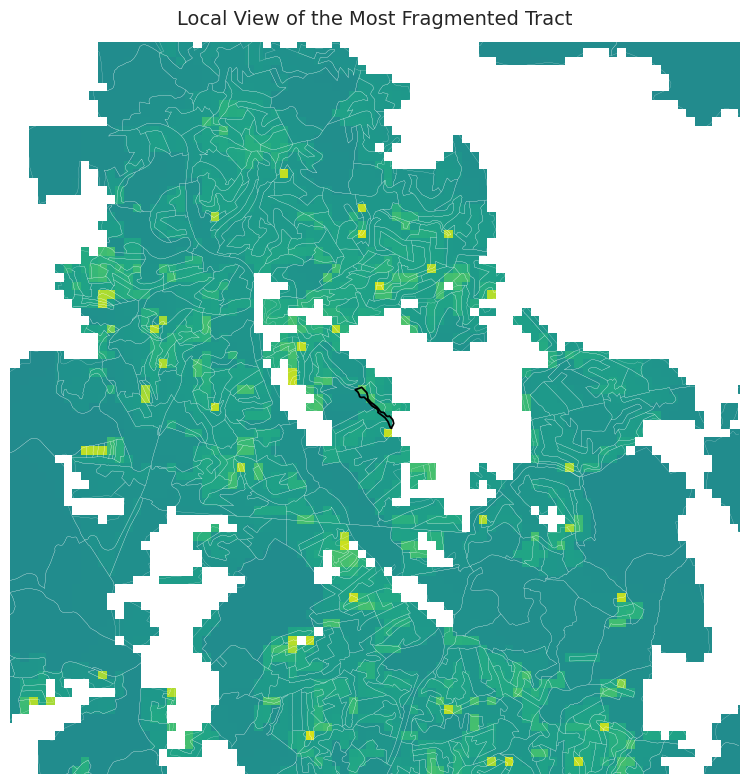

In [ ]:
# ============================================================
# SECTION 6.5 — Local view of the most fragmented tract
# ============================================================

if "fragmentation_index" not in sp_metric.columns:
    raise RuntimeError("Fragmentation diagnostics are not available. Run the previous cell first.")

most_fragmented_tract = sp_metric.dropna(subset=["fragmentation_index"]).sort_values(
    "fragmentation_index", ascending=False
).iloc[0]

focus_geom = most_fragmented_tract.geometry.buffer(focus_buffer_m)
fxmin, fymin, fxmax, fymax = focus_geom.bounds

fig, ax = plt.subplots(figsize=(8, 8), facecolor="white")

ax.imshow(
    mii_norm_100m,
    cmap="viridis",
    extent=(xmin, xmax, ymin, ymax),
    origin="upper",
    interpolation="nearest",
)

sp_metric.boundary.plot(ax=ax, color="white", linewidth=0.12)
sp_metric.loc[[most_fragmented_tract.name]].boundary.plot(ax=ax, color="black", linewidth=1.3)

ax.set_xlim(fxmin, fxmax)
ax.set_ylim(fymin, fymax)
ax.set_title("Local View of the Most Fragmented Tract", fontsize=14, pad=12)
ax.set_axis_off()

plt.tight_layout()
plt.show()

The fragmentation diagnostics showed that many census tracts concealed substantial internal differentiation. Even when a tract appeared relatively coherent in the tract-level surface, the downscaled reconstruction often revealed localized pockets of concentration and attenuation within the same administrative unit.

This mattered for applied spatial diagnosis because tract-level averages could still mask where infrastructure mass actually concentrated inside urban space. In the final section, we synthesized the main findings, clarified the framework's scope, and restated the notebook’s reproducible logic.

# 7. Key Takeaways, Limitations, and Reproducibility

This final section consolidated the notebook's main results, clarified the framework's scope, and restated the workflow's reproducible logic.

Taken together, the previous sections showed that mobility data could reveal more than traffic volume alone. By modeling the covariance structure of tract-level mobility behavior, we recovered a latent infrastructure field, identified spatially differentiated mobility environments, validated those environments against an external economic benchmark, and showed that tract-level representation still concealed substantial internal variation.

We conclude by summarizing the main findings, clarifying the limits of the current implementation, and restating why the workflow mattered for reproducible spatial decision support.

In [ ]:
# ============================================================
# SECTION 7 — Executive summary table
# ============================================================

summary_rows = []

if "explained_variance_df" in globals():
    summary_rows.append(
        {
            "stage": "Latent structure recovery",
            "result": f"PC1 explained {explained_variance_df.loc[0, 'explained_variance_ratio']:.4f} of total variance",
        }
    )

if "alignment_summary" in globals():
    summary_rows.append(
        {
            "stage": "MII consistency check",
            "result": f"Recomputed PC1 and stored MII correlation = {alignment_summary.loc[0, 'correlation_between_recomputed_pc1_and_stored_mii']:.4f}",
        }
    )

if "regime_assignment_summary" in globals():
    n_regimes_found = int(regime_assignment_summary["infrastructure_regime"].nunique())
    summary_rows.append(
        {
            "stage": "Spatial regime discovery",
            "result": f"{n_regimes_found} tract-level regimes were recovered and propagated across valid census tracts",
        }
    )
elif "tract_regime_counts" in globals():
    n_regimes_found = int(tract_regime_counts["infrastructure_regime"].dropna().nunique())
    summary_rows.append(
        {
            "stage": "Spatial regime discovery",
            "result": f"{n_regimes_found} tract-level regimes were recovered and propagated across valid census tracts",
        }
    )

if "regime_nightlight_summary" in globals():
    summary_rows.append(
        {
            "stage": "Economic validation",
            "result": "Nighttime light intensity differed across mobility infrastructure regimes",
        }
    )

if "mass_preservation_summary" in globals():
    max_diff = float(mass_preservation_summary.loc[0, "max_absolute_tract_difference"])
    summary_rows.append(
        {
            "stage": "Multiscale reconstruction",
            "result": f"Mass-preserving redistribution was completed (max tract difference = {max_diff:.6f})",
        }
    )

if "fragmentation_summary" in globals():
    summary_rows.append(
        {
            "stage": "Intra-tract fragmentation",
            "result": "Downscaling revealed substantial internal differentiation within selected tracts",
        }
    )

executive_summary_df = pd.DataFrame(summary_rows)
display(executive_summary_df)

,stage,result
0,Latent structure recovery,PC1 explained 0.6143 of total variance
1,MII consistency check,Recomputed PC1 and stored MII correlation = 0.9447
2,Spatial regime discovery,4 tract-level regimes were recovered and propagated across valid census tracts
3,Economic validation,Nighttime light intensity differed across mobility infrastructure regimes
4,Multiscale reconstruction,Mass-preserving redistribution was completed (max tract difference = 2.750485)
5,Intra-tract fragmentation,Downscaling revealed substantial internal differentiation within selected tracts


### 7.1 Key takeaways

The notebook produced four main findings.

**First, mobility intensity alone was not sufficient to characterize local infrastructure conditions.**  
The seven mobility indicators did not behave as isolated signals. Instead, they exhibited a strong common dimension, showing that visitation intensity, recurrence, dwell time, and temporal stability were jointly organized across space. This meant that movement could be interpreted as a richer behavioral structure rather than as a single count of exposure.

**Second, this latent dimension was spatially heterogeneous rather than nationally uniform.**  
After moving from a national covariance structure to localized covariance signatures, we recovered multiple **mobility infrastructure regimes**. This showed that places with similar apparent activity could still belong to structurally different local mobility environments.

**Third, the recovered regimes were economically meaningful.**  
When we linked them to tract-level VIIRS nighttime light intensity, the regimes differed not only in average economic environment but also in the shape of the mobility-economic relationship. Similar levels of traffic did not imply equivalent economic contexts once the underlying mobility structures of places were taken into account.

**Fourth, tract-level representation still concealed important internal variation.**  
The mass-preserving downscaling exercise showed that many tracts contained substantial sub-tract heterogeneity. Even when the tract-level surface appeared coherent, the reconstructed 100-meter surface often revealed localized pockets of concentration and attenuation that remained hidden at the administrative scale.

Taken together, these findings supported the notebook’s central claim: mobility data could be used to recover a latent, spatially differentiated, and decision-relevant infrastructure field rather than simply map traffic.

### 7.2 Why this framework matters

This framework mattered because many real-world decisions still relied on traffic counts or static territorial proxies that could not distinguish transient exposure from places characterized by recurring access, stable visitation, and stronger local activation. The notebook showed that mobility data could support a more discriminating view of place performance by recovering the behavioral structure underlying observed movement rather than relying on volume alone.

For **firms**, that distinction helped separate high-exposure corridors from places where movement was more consistently organized around recurring local engagement. For **entrepreneurs**, it helped identify areas where visible activity was more likely to reflect repeat-use environments rather than short-lived circulation. For **urban planners**, it helped identify tracts that appeared active on the surface but differed in stability, economic significance, and the internal concentration of local activity. For **researchers**, it provided a transferable Spatial AI workflow for recovering latent infrastructure conditions from behaviorally structured mobility data.

The empirical demonstration focused on Brazil, but the analytical logic was portable. Where comparable mobility and geospatial assets were available, the same workflow could be adapted to other national settings, metropolitan systems, and planning contexts. Its value did not depend on reproducing this exact case. It depended on showing that movement data could be converted into a more decision-relevant representation of local spatial conditions than traffic alone could provide.

### 7.3 Limitations

The notebook also had clear limitations.

**First, the mobility data were proprietary and pre-aggregated.**  
Although the shared GeoPackage made the workflow reproducible at the analytical stage, exact replication from the original provider inputs would still require access to the same commercial mobility source.

**Second, the framework was structural rather than causal.**  
The analyses identified mobility-based infrastructure conditions associated with local economic intensity, but they did not estimate causal effects or isolate exogenous variation in local activity.

**Third, the empirical demonstration used a single national setting and a limited temporal frame.**  
The mobility indicators reflected a specific aggregated observation window, and the economic validation relied on annual nighttime light intensity for a comparable period. A richer temporal design could examine how mobility-based infrastructure evolved over time.

**Fourth, the downscaling exercise was intentionally framed as a reconstruction rather than a direct observation of micro-scale market outcomes.**  
Its purpose was to reveal concealed intra-tract variation while preserving tract-level consistency, not to claim that the 100-meter surface directly measured ground-truth economic activity at that scale.

These limitations did not diminish the value of the framework. Instead, they clarified its current scope and identified the main directions for extension and refinement.

### 7.4 Reproducibility

The notebook was designed to be reproducible from the two platform-ready assets introduced in Section 2:

- the **analysis-ready GeoPackage**, which contained tract geometry, standardized mobility indicators, the stored `mii`, and `mii_norm`; and
- the **VIIRS nighttime lights archive**, which supported external economic validation and multiscale reconstruction.

Because the workflow began from these shared assets, reviewers did not need access to internal preprocessing directories, proprietary local paths, or undocumented intermediate products. The notebook reproduced the framework's analytical logic directly from the materials provided via the platform.

This design was intentional. It allowed the notebook to function not only as a demonstration of results, but also as a transparent and portable implementation of the analytical workflow itself.

### 7.5 Final conclusion

This notebook showed that places with similar traffic could differ systematically in their underlying access conditions, economic context, and internal spatial organization. By modeling the structured organization of visitation behavior, we recovered a latent field of **market infrastructure**, showed that this field varied across distinct spatial regimes, demonstrated that those regimes aligned with different economic environments, and revealed that tract-level representation still masked important sub-tract variation.

The notebook’s central contribution was therefore not simply to map mobility. It was to show that mobility could be analyzed as a behavioral system whose latent structure helped distinguish pass-through activity from places characterized by recurring access and more persistent local activation. That distinction made the framework more informative than traffic counts alone for comparative spatial diagnosis.

In practical terms, this framework offered a reproducible way to support location assessment, urban targeting, and spatial comparison in settings where raw movement intensity was too coarse to capture meaningful differences between places. It did not provide a causal account of local economic performance, nor did it function as a turnkey decision rule. Instead, it provided a decision-relevant analytical lens for recovering hidden spatial structure from human mobility data and making that structure empirically visible across scales.

### 7.6 References and project materials

For the conceptual and methodological background of the framework, readers should refer to the accompanying manuscript. For the full reproducible workflow, analytical logic, and supporting project materials, readers should refer to the project repository: `RPAlbuquerque/gsdm-spatial-ai`.

The notebook was designed to work directly from the platform-ready assets introduced in Section 2, allowing reviewers to reproduce the workflow without relying on hidden preprocessing directories or undocumented local state.